In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

from sklearn.linear_model import LinearRegression

from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix,
                             RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay,
                             precision_recall_curve, roc_curve, auc)

import joblib
from joblib import Parallel, delayed
import time

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
import matplotlib
import sklearn
import xgboost
import lightgbm
import catboost

print(np.__version__)
print(pd.__version__)
print(matplotlib.__version__)
print(sns.__version__)

print(sklearn.__version__)
print(xgboost.__version__)
print(lightgbm.__version__)
print(catboost.__version__)

2.2.6
2.3.3
3.10.8
0.13.2
1.7.2
3.1.3
4.6.0
1.2.8


In [4]:
SEED = 42

np.random.seed(SEED)

# data import

In [5]:
path = '/home/leewen/code/physionet'

In [6]:
X_train_linear = pd.read_csv(path + '/X_train_linear.csv')
X_test_linear = pd.read_csv(path + '/X_test_linear.csv')
X_train_smote = pd.read_csv(path + '/X_train_smote.csv')
X_test_smote = pd.read_csv(path + '/X_test_smote.csv')
X_train_tree = pd.read_csv(path + '/X_train_tree.csv')
X_test_tree = pd.read_csv(path + '/X_test_tree.csv')
y_train = pd.read_csv(path + '/y_train.csv')
y_test = pd.read_csv(path + '/y_test.csv')

In [7]:
X_train_linear.head(10)

,Albumin_Initial,Albumin_Min,Albumin_Max,Albumin_Mean,ALP_Initial,ALP_Max,ALT_Initial,ALT_Max,AST_Initial,AST_Max,Bilirubin_Initial,Bilirubin_Max,BUN_Initial,BUN_Max,BUN_Mean,BUN_Creatinine_Ratio,Cholesterol_Initial,Cholesterol_Min,Creatinine_Initial,Creatinine_Max,Creatinine_Mean,FiO2_Initial,FiO2_Max,FiO2_Mean,GCS_Initial,GCS_Final,GCS_Min,GCS_Max,GCS_Mean,Glucose_Initial,Glucose_Min,Glucose_Max,Glucose_Mean,HCO3_Initial,HCO3_Final,HCO3_Min,HCO3_Max,HCT_Initial,HCT_Min,HCT_Max,HCT_Mean,HR_Initial,HR_Final,HR_Min,HR_Max,HR_Mean,HR_SD,K_Initial,K_Final,K_Min,K_Max,K_Mean,Lactate_Initial,Lactate_Max,Lactate_Clearance_Rate_6H,Lactate_Clearance_Rate_12H,MechVent_Any,Mg_Initial,Mg_Min,Mg_Max,Na_Initial,Na_Final,Na_Min,Na_Max,Na_Mean,PaCO2_Initial,PaCO2_Min,PaCO2_Max,PaO2_Initial,PaO2_Min,PaO2_FiO2_Ratio,pH_Initial,pH_Min,pH_Max,pH_Mean,Platelets_Initial,Platelets_Min,RespRate_Initial,RespRate_Max,RespRate_Mean,SaO2_Initial,SaO2_Min,Temp_Initial,Temp_Min,Temp_Max,Temp_Mean,Temp_SD,Urine_Sum,Urine_MinRate,Urine_MaxRate,Urine_MeanRate,WBC_Initial,WBC_Min,WBC_Max,Weight_Initial,Weight_Final,UniDiasABP_Initial,UniDiasABP_Min,UniDiasABP_Max,UniDiasABP_Mean,UniMAP_Initial,UniMAP_Final,UniMAP_Min,UniMAP_Max,UniMAP_Mean,UniMAP_SD,UniSysABP_Initial,UniSysABP_Final,UniSysABP_Min,UniSysABP_Max,UniSysABP_Mean,UniSysABP_SD,Troponin_Max,Albumin_Log_Count,ALP_Log_Count,ALT_Log_Count,AST_Log_Count,BUN_Log_Count,Bilirubin_Log_Count,Cholesterol_Log_Count,Creatinine_Log_Count,FiO2_Log_Count,GCS_Log_Count,Glucose_Log_Count,HCO3_Log_Count,HCT_Log_Count,HR_Log_Count,K_Log_Count,Lactate_Log_Count,MechVent_Log_Count,Mg_Log_Count,Na_Log_Count,PaCO2_Log_Count,PaO2_Log_Count,pH_Log_Count,Platelets_Log_Count,RespRate_Log_Count,SaO2_Log_Count,Temp_Log_Count,Urine_Log_Count,WBC_Log_Count,UniDiasABP_Log_Count,UniMAP_Log_Count,UniSysABP_Log_Count,Troponin_Log_Count,Albumin_Delta,ALP_Delta,ALT_Delta,AST_Delta,Bilirubin_Delta,BUN_Delta,Cholesterol_Delta,Creatinine_Delta,HCO3_Delta,HCT_Delta,K_Delta,Mg_Delta,Na_Delta,PaO2_Delta,Platelets_Delta,SaO2_Delta,WBC_Delta,Weight_Delta,Troponin_Delta,FiO2_Slope,GCS_Slope,Glucose_Slope,HR_Slope,PaCO2_Slope,pH_Slope,RespRate_Slope,Temp_Slope,Urine_Rate_Slope,UniDiasABP_Slope,UniMAP_Slope,UniSysABP_Slope,Albumin_Miss,ALP_Miss,ALT_Miss,AST_Miss,Bilirubin_Miss,BUN_Miss,Cholesterol_Miss,Creatinine_Miss,FiO2_Miss,GCS_Miss,Glucose_Miss,HCO3_Miss,HCT_Miss,HR_Miss,K_Miss,Lactate_Miss,MechVent_Miss,Mg_Miss,Na_Miss,PaCO2_Miss,PaO2_Miss,pH_Miss,Platelets_Miss,RespRate_Miss,SaO2_Miss,Temp_Miss,Urine_Miss,WBC_Miss,Weight_Miss,UniDiasABP_Miss,UniMAP_Miss,UniSysABP_Miss,Troponin_Miss,Albumin_Last_Gap,ALP_Last_Gap,ALT_Last_Gap,AST_Last_Gap,Bilirubin_Last_Gap,BUN_Last_Gap,Cholesterol_Last_Gap,Creatinine_Last_Gap,FiO2_Last_Gap,GCS_Last_Gap,Glucose_Last_Gap,HCO3_Last_Gap,HCT_Last_Gap,HR_Last_Gap,K_Last_Gap,Lactate_Last_Gap,MechVent_Last_Gap,Mg_Last_Gap,Na_Last_Gap,PaCO2_Last_Gap,PaO2_Last_Gap,pH_Last_Gap,Platelets_Last_Gap,RespRate_Last_Gap,SaO2_Last_Gap,Temp_Last_Gap,Urine_Last_Gap,WBC_Last_Gap,Weight_Last_Gap,UniDiasABP_Last_Gap,UniMAP_Last_Gap,UniSysABP_Last_Gap,Troponin_Last_Gap,Global_Last_Gap,Total_Obs_Count,Total_Missing_Sum,Shock_Index,GCS_MAP_Product,Net_Cation_Balance,Age,Gender,Height,ICUType_1.0,ICUType_2.0,ICUType_3.0,ICUType_4.0
0,0.043806,0.019069,0.005296,-0.037088,-0.175259,-0.207376,0.617544,0.388429,0.608342,0.339159,-0.208014,-0.241122,0.011620,-0.095195,0.043514,-0.458196,-0.019451,-0.017062,0.034924,0.041906,0.110260,-1.525112,-1.866613,-1.200147,-0.005787,-0.394672,0.369010,-0.976697,-0.382628,1.585857,0.566954,1.057045,1.123359,-0.693337,-1.483015,-0.860751,-0.837875,0.889310,1.097191,0.876515,1.027405,-2.150841,-0.865905,-1.976843,-1.327389,-2.047022,-0.194677,0.459301,0.638111,-0.496313,-0.065618,0.007035,0.476987,0.162761,0.304278,1.262430,0.0,-0.512210,-0.247878,-0.374130,0.259736,0.257381,0.242835,-0.165738,0.111927,-1.493286,-1.094913,-0.520759,0.286135,-0.687199,0.041722,1.192960,-0.005638,0.542476,-0.138047,-1.314

In [8]:
X_test_linear.head(10)

,Albumin_Initial,Albumin_Min,Albumin_Max,Albumin_Mean,ALP_Initial,ALP_Max,ALT_Initial,ALT_Max,AST_Initial,AST_Max,Bilirubin_Initial,Bilirubin_Max,BUN_Initial,BUN_Max,BUN_Mean,BUN_Creatinine_Ratio,Cholesterol_Initial,Cholesterol_Min,Creatinine_Initial,Creatinine_Max,Creatinine_Mean,FiO2_Initial,FiO2_Max,FiO2_Mean,GCS_Initial,GCS_Final,GCS_Min,GCS_Max,GCS_Mean,Glucose_Initial,Glucose_Min,Glucose_Max,Glucose_Mean,HCO3_Initial,HCO3_Final,HCO3_Min,HCO3_Max,HCT_Initial,HCT_Min,HCT_Max,HCT_Mean,HR_Initial,HR_Final,HR_Min,HR_Max,HR_Mean,HR_SD,K_Initial,K_Final,K_Min,K_Max,K_Mean,Lactate_Initial,Lactate_Max,Lactate_Clearance_Rate_6H,Lactate_Clearance_Rate_12H,MechVent_Any,Mg_Initial,Mg_Min,Mg_Max,Na_Initial,Na_Final,Na_Min,Na_Max,Na_Mean,PaCO2_Initial,PaCO2_Min,PaCO2_Max,PaO2_Initial,PaO2_Min,PaO2_FiO2_Ratio,pH_Initial,pH_Min,pH_Max,pH_Mean,Platelets_Initial,Platelets_Min,RespRate_Initial,RespRate_Max,RespRate_Mean,SaO2_Initial,SaO2_Min,Temp_Initial,Temp_Min,Temp_Max,Temp_Mean,Temp_SD,Urine_Sum,Urine_MinRate,Urine_MaxRate,Urine_MeanRate,WBC_Initial,WBC_Min,WBC_Max,Weight_Initial,Weight_Final,UniDiasABP_Initial,UniDiasABP_Min,UniDiasABP_Max,UniDiasABP_Mean,UniMAP_Initial,UniMAP_Final,UniMAP_Min,UniMAP_Max,UniMAP_Mean,UniMAP_SD,UniSysABP_Initial,UniSysABP_Final,UniSysABP_Min,UniSysABP_Max,UniSysABP_Mean,UniSysABP_SD,Troponin_Max,Albumin_Log_Count,ALP_Log_Count,ALT_Log_Count,AST_Log_Count,BUN_Log_Count,Bilirubin_Log_Count,Cholesterol_Log_Count,Creatinine_Log_Count,FiO2_Log_Count,GCS_Log_Count,Glucose_Log_Count,HCO3_Log_Count,HCT_Log_Count,HR_Log_Count,K_Log_Count,Lactate_Log_Count,MechVent_Log_Count,Mg_Log_Count,Na_Log_Count,PaCO2_Log_Count,PaO2_Log_Count,pH_Log_Count,Platelets_Log_Count,RespRate_Log_Count,SaO2_Log_Count,Temp_Log_Count,Urine_Log_Count,WBC_Log_Count,UniDiasABP_Log_Count,UniMAP_Log_Count,UniSysABP_Log_Count,Troponin_Log_Count,Albumin_Delta,ALP_Delta,ALT_Delta,AST_Delta,Bilirubin_Delta,BUN_Delta,Cholesterol_Delta,Creatinine_Delta,HCO3_Delta,HCT_Delta,K_Delta,Mg_Delta,Na_Delta,PaO2_Delta,Platelets_Delta,SaO2_Delta,WBC_Delta,Weight_Delta,Troponin_Delta,FiO2_Slope,GCS_Slope,Glucose_Slope,HR_Slope,PaCO2_Slope,pH_Slope,RespRate_Slope,Temp_Slope,Urine_Rate_Slope,UniDiasABP_Slope,UniMAP_Slope,UniSysABP_Slope,Albumin_Miss,ALP_Miss,ALT_Miss,AST_Miss,Bilirubin_Miss,BUN_Miss,Cholesterol_Miss,Creatinine_Miss,FiO2_Miss,GCS_Miss,Glucose_Miss,HCO3_Miss,HCT_Miss,HR_Miss,K_Miss,Lactate_Miss,MechVent_Miss,Mg_Miss,Na_Miss,PaCO2_Miss,PaO2_Miss,pH_Miss,Platelets_Miss,RespRate_Miss,SaO2_Miss,Temp_Miss,Urine_Miss,WBC_Miss,Weight_Miss,UniDiasABP_Miss,UniMAP_Miss,UniSysABP_Miss,Troponin_Miss,Albumin_Last_Gap,ALP_Last_Gap,ALT_Last_Gap,AST_Last_Gap,Bilirubin_Last_Gap,BUN_Last_Gap,Cholesterol_Last_Gap,Creatinine_Last_Gap,FiO2_Last_Gap,GCS_Last_Gap,Glucose_Last_Gap,HCO3_Last_Gap,HCT_Last_Gap,HR_Last_Gap,K_Last_Gap,Lactate_Last_Gap,MechVent_Last_Gap,Mg_Last_Gap,Na_Last_Gap,PaCO2_Last_Gap,PaO2_Last_Gap,pH_Last_Gap,Platelets_Last_Gap,RespRate_Last_Gap,SaO2_Last_Gap,Temp_Last_Gap,Urine_Last_Gap,WBC_Last_Gap,Weight_Last_Gap,UniDiasABP_Last_Gap,UniMAP_Last_Gap,UniSysABP_Last_Gap,Troponin_Last_Gap,Global_Last_Gap,Total_Obs_Count,Total_Missing_Sum,Shock_Index,GCS_MAP_Product,Net_Cation_Balance,Age,Gender,Height,ICUType_1.0,ICUType_2.0,ICUType_3.0,ICUType_4.0
0,-0.430781,-0.216540,-0.482986,-0.281166,-0.291522,-0.294959,-0.077404,-0.103939,-0.094208,-0.113626,1.452775,1.285497,-0.268303,-0.270024,-0.241623,0.691479,-0.019451,-0.017062,-0.448363,-0.459321,-0.454460,0.636300,0.55289,-0.152063,1.017896,0.711876,1.411458,0.555026,1.036857,-1.065412,-1.432801,0.043769,-1.028674,0.384648,-0.305524,0.242322,0.134327,-0.603095,-0.274274,-0.326557,-0.369233,-0.538503,0.067993,0.320756,-1.100921,-0.486345,-1.357204,-0.240267,-0.926548,-0.299186,-0.774756,-0.694056,-0.251297,-0.230230,-0.003023,0.025472,0.0,0.154566,-0.537819,-0.628520,-1.244617,-1.798710,-1.354391,-1.291316,-1.373396,-0.117568,-0.072738,-0.115809,-0.233979,-0.222758,-0.164222,0.090292,0.120361,-0.013630,0

In [9]:
X_train_smote.head(10)

,Albumin_Initial,Albumin_Min,Albumin_Max,Albumin_Mean,ALP_Initial,ALP_Max,ALT_Initial,ALT_Max,AST_Initial,AST_Max,Bilirubin_Initial,Bilirubin_Max,BUN_Initial,BUN_Max,BUN_Mean,BUN_Creatinine_Ratio,Cholesterol_Initial,Cholesterol_Min,Creatinine_Initial,Creatinine_Max,Creatinine_Mean,FiO2_Initial,FiO2_Max,FiO2_Mean,GCS_Initial,GCS_Final,GCS_Min,GCS_Max,GCS_Mean,Glucose_Initial,Glucose_Min,Glucose_Max,Glucose_Mean,HCO3_Initial,HCO3_Final,HCO3_Min,HCO3_Max,HCT_Initial,HCT_Min,HCT_Max,HCT_Mean,HR_Initial,HR_Final,HR_Min,HR_Max,HR_Mean,HR_SD,K_Initial,K_Final,K_Min,K_Max,K_Mean,Lactate_Initial,Lactate_Max,Lactate_Clearance_Rate_6H,Lactate_Clearance_Rate_12H,MechVent_Any,Mg_Initial,Mg_Min,Mg_Max,Na_Initial,Na_Final,Na_Min,Na_Max,Na_Mean,PaCO2_Initial,PaCO2_Min,PaCO2_Max,PaO2_Initial,PaO2_Min,PaO2_FiO2_Ratio,pH_Initial,pH_Min,pH_Max,pH_Mean,Platelets_Initial,Platelets_Min,RespRate_Initial,RespRate_Max,RespRate_Mean,SaO2_Initial,SaO2_Min,Temp_Initial,Temp_Min,Temp_Max,Temp_Mean,Temp_SD,Urine_Sum,Urine_MinRate,Urine_MaxRate,Urine_MeanRate,WBC_Initial,WBC_Min,WBC_Max,Weight_Initial,Weight_Final,UniDiasABP_Initial,UniDiasABP_Min,UniDiasABP_Max,UniDiasABP_Mean,UniMAP_Initial,UniMAP_Final,UniMAP_Min,UniMAP_Max,UniMAP_Mean,UniMAP_SD,UniSysABP_Initial,UniSysABP_Final,UniSysABP_Min,UniSysABP_Max,UniSysABP_Mean,UniSysABP_SD,Troponin_Max,Albumin_Log_Count,ALP_Log_Count,ALT_Log_Count,AST_Log_Count,BUN_Log_Count,Bilirubin_Log_Count,Cholesterol_Log_Count,Creatinine_Log_Count,FiO2_Log_Count,GCS_Log_Count,Glucose_Log_Count,HCO3_Log_Count,HCT_Log_Count,HR_Log_Count,K_Log_Count,Lactate_Log_Count,MechVent_Log_Count,Mg_Log_Count,Na_Log_Count,PaCO2_Log_Count,PaO2_Log_Count,pH_Log_Count,Platelets_Log_Count,RespRate_Log_Count,SaO2_Log_Count,Temp_Log_Count,Urine_Log_Count,WBC_Log_Count,UniDiasABP_Log_Count,UniMAP_Log_Count,UniSysABP_Log_Count,Troponin_Log_Count,Albumin_Delta,ALP_Delta,ALT_Delta,AST_Delta,Bilirubin_Delta,BUN_Delta,Cholesterol_Delta,Creatinine_Delta,HCO3_Delta,HCT_Delta,K_Delta,Mg_Delta,Na_Delta,PaO2_Delta,Platelets_Delta,SaO2_Delta,WBC_Delta,Weight_Delta,Troponin_Delta,FiO2_Slope,GCS_Slope,Glucose_Slope,HR_Slope,PaCO2_Slope,pH_Slope,RespRate_Slope,Temp_Slope,Urine_Rate_Slope,UniDiasABP_Slope,UniMAP_Slope,UniSysABP_Slope,Albumin_Miss,ALP_Miss,ALT_Miss,AST_Miss,Bilirubin_Miss,BUN_Miss,Cholesterol_Miss,Creatinine_Miss,FiO2_Miss,GCS_Miss,Glucose_Miss,HCO3_Miss,HCT_Miss,HR_Miss,K_Miss,Lactate_Miss,MechVent_Miss,Mg_Miss,Na_Miss,PaCO2_Miss,PaO2_Miss,pH_Miss,Platelets_Miss,RespRate_Miss,SaO2_Miss,Temp_Miss,Urine_Miss,WBC_Miss,Weight_Miss,UniDiasABP_Miss,UniMAP_Miss,UniSysABP_Miss,Troponin_Miss,Albumin_Last_Gap,ALP_Last_Gap,ALT_Last_Gap,AST_Last_Gap,Bilirubin_Last_Gap,BUN_Last_Gap,Cholesterol_Last_Gap,Creatinine_Last_Gap,FiO2_Last_Gap,GCS_Last_Gap,Glucose_Last_Gap,HCO3_Last_Gap,HCT_Last_Gap,HR_Last_Gap,K_Last_Gap,Lactate_Last_Gap,MechVent_Last_Gap,Mg_Last_Gap,Na_Last_Gap,PaCO2_Last_Gap,PaO2_Last_Gap,pH_Last_Gap,Platelets_Last_Gap,RespRate_Last_Gap,SaO2_Last_Gap,Temp_Last_Gap,Urine_Last_Gap,WBC_Last_Gap,Weight_Last_Gap,UniDiasABP_Last_Gap,UniMAP_Last_Gap,UniSysABP_Last_Gap,Troponin_Last_Gap,Global_Last_Gap,Total_Obs_Count,Total_Missing_Sum,Shock_Index,GCS_MAP_Product,Net_Cation_Balance,Age,Gender,Height,ICUType_1.0,ICUType_2.0,ICUType_3.0,ICUType_4.0
0,3.0,2.9,3.0,2.9,76.0,76.0,339.0,339.0,500.0,500.0,0.6,0.6,26.0,27.0,26.333333,18.571429,153.0,153.0,1.4,1.6,1.500000,0.50,0.5,0.411765,10.0,11.0,10.0,11.0,10.413793,260.0,125.0,260.0,180.666667,20.0,18.0,18.0,22.0,37.1,34.2,38.2,35.880000,47.0,71.0,41.0,83.0,57.071429,9.222220,4.5,4.4,3.5,4.5,4.133333,3.1,3.1,12.903226,54.838710,1.0,1.7,1.7,2.1,140.0,140.0,138.0,140.0,139.333333,27.0,27.0,42.0,227.0,65.0,162.500000,7.47,7.32,7.47,7.377692,68.0,62.0,19.0,28.0,19.071762,98.0,96.0,36.2,36.2,37.6,37.016071,0.357149,2185.0,0.223430,1.787443,0.496472,10.3,10.3,12.2,56.8,67.4,66.0,51.0,73.0,61.035088,82.0,91.00,68.00,96.0,79.892857,6.317878,114.0,123.0,100.0,134.0,113.561404,7.618159,0.28,0.000000,0.693147,0.693

In [10]:
X_test_smote.head(10)

,Albumin_Initial,Albumin_Min,Albumin_Max,Albumin_Mean,ALP_Initial,ALP_Max,ALT_Initial,ALT_Max,AST_Initial,AST_Max,Bilirubin_Initial,Bilirubin_Max,BUN_Initial,BUN_Max,BUN_Mean,BUN_Creatinine_Ratio,Cholesterol_Initial,Cholesterol_Min,Creatinine_Initial,Creatinine_Max,Creatinine_Mean,FiO2_Initial,FiO2_Max,FiO2_Mean,GCS_Initial,GCS_Final,GCS_Min,GCS_Max,GCS_Mean,Glucose_Initial,Glucose_Min,Glucose_Max,Glucose_Mean,HCO3_Initial,HCO3_Final,HCO3_Min,HCO3_Max,HCT_Initial,HCT_Min,HCT_Max,HCT_Mean,HR_Initial,HR_Final,HR_Min,HR_Max,HR_Mean,HR_SD,K_Initial,K_Final,K_Min,K_Max,K_Mean,Lactate_Initial,Lactate_Max,Lactate_Clearance_Rate_6H,Lactate_Clearance_Rate_12H,MechVent_Any,Mg_Initial,Mg_Min,Mg_Max,Na_Initial,Na_Final,Na_Min,Na_Max,Na_Mean,PaCO2_Initial,PaCO2_Min,PaCO2_Max,PaO2_Initial,PaO2_Min,PaO2_FiO2_Ratio,pH_Initial,pH_Min,pH_Max,pH_Mean,Platelets_Initial,Platelets_Min,RespRate_Initial,RespRate_Max,RespRate_Mean,SaO2_Initial,SaO2_Min,Temp_Initial,Temp_Min,Temp_Max,Temp_Mean,Temp_SD,Urine_Sum,Urine_MinRate,Urine_MaxRate,Urine_MeanRate,WBC_Initial,WBC_Min,WBC_Max,Weight_Initial,Weight_Final,UniDiasABP_Initial,UniDiasABP_Min,UniDiasABP_Max,UniDiasABP_Mean,UniMAP_Initial,UniMAP_Final,UniMAP_Min,UniMAP_Max,UniMAP_Mean,UniMAP_SD,UniSysABP_Initial,UniSysABP_Final,UniSysABP_Min,UniSysABP_Max,UniSysABP_Mean,UniSysABP_SD,Troponin_Max,Albumin_Log_Count,ALP_Log_Count,ALT_Log_Count,AST_Log_Count,BUN_Log_Count,Bilirubin_Log_Count,Cholesterol_Log_Count,Creatinine_Log_Count,FiO2_Log_Count,GCS_Log_Count,Glucose_Log_Count,HCO3_Log_Count,HCT_Log_Count,HR_Log_Count,K_Log_Count,Lactate_Log_Count,MechVent_Log_Count,Mg_Log_Count,Na_Log_Count,PaCO2_Log_Count,PaO2_Log_Count,pH_Log_Count,Platelets_Log_Count,RespRate_Log_Count,SaO2_Log_Count,Temp_Log_Count,Urine_Log_Count,WBC_Log_Count,UniDiasABP_Log_Count,UniMAP_Log_Count,UniSysABP_Log_Count,Troponin_Log_Count,Albumin_Delta,ALP_Delta,ALT_Delta,AST_Delta,Bilirubin_Delta,BUN_Delta,Cholesterol_Delta,Creatinine_Delta,HCO3_Delta,HCT_Delta,K_Delta,Mg_Delta,Na_Delta,PaO2_Delta,Platelets_Delta,SaO2_Delta,WBC_Delta,Weight_Delta,Troponin_Delta,FiO2_Slope,GCS_Slope,Glucose_Slope,HR_Slope,PaCO2_Slope,pH_Slope,RespRate_Slope,Temp_Slope,Urine_Rate_Slope,UniDiasABP_Slope,UniMAP_Slope,UniSysABP_Slope,Albumin_Miss,ALP_Miss,ALT_Miss,AST_Miss,Bilirubin_Miss,BUN_Miss,Cholesterol_Miss,Creatinine_Miss,FiO2_Miss,GCS_Miss,Glucose_Miss,HCO3_Miss,HCT_Miss,HR_Miss,K_Miss,Lactate_Miss,MechVent_Miss,Mg_Miss,Na_Miss,PaCO2_Miss,PaO2_Miss,pH_Miss,Platelets_Miss,RespRate_Miss,SaO2_Miss,Temp_Miss,Urine_Miss,WBC_Miss,Weight_Miss,UniDiasABP_Miss,UniMAP_Miss,UniSysABP_Miss,Troponin_Miss,Albumin_Last_Gap,ALP_Last_Gap,ALT_Last_Gap,AST_Last_Gap,Bilirubin_Last_Gap,BUN_Last_Gap,Cholesterol_Last_Gap,Creatinine_Last_Gap,FiO2_Last_Gap,GCS_Last_Gap,Glucose_Last_Gap,HCO3_Last_Gap,HCT_Last_Gap,HR_Last_Gap,K_Last_Gap,Lactate_Last_Gap,MechVent_Last_Gap,Mg_Last_Gap,Na_Last_Gap,PaCO2_Last_Gap,PaO2_Last_Gap,pH_Last_Gap,Platelets_Last_Gap,RespRate_Last_Gap,SaO2_Last_Gap,Temp_Last_Gap,Urine_Last_Gap,WBC_Last_Gap,Weight_Last_Gap,UniDiasABP_Last_Gap,UniMAP_Last_Gap,UniSysABP_Last_Gap,Troponin_Last_Gap,Global_Last_Gap,Total_Obs_Count,Total_Missing_Sum,Shock_Index,GCS_MAP_Product,Net_Cation_Balance,Age,Gender,Height,ICUType_1.0,ICUType_2.0,ICUType_3.0,ICUType_4.0
0,2.8,2.8,2.8,2.80,66.0,68.0,49.0,50.0,65.0,70.0,5.6,5.6,20.0,23.0,20.500000,33.333333,153.0,153.0,0.7,0.8,0.725000,1.0,1.0,0.526120,15.0,15.0,15.0,15.0,15.000000,73.0,67.0,176.0,96.750000,25.0,23.0,23.0,26.0,28.3,27.1,32.5,29.680000,79.0,87.0,73.0,88.0,79.910714,3.824689,4.0,3.6,3.6,4.0,3.800000,1.9,2.3,0.000000,10.000000,1.0,2.0,1.6,2.0,133.0,131.0,131.0,135.0,133.250000,40.0,34.0,46.0,171.0,82.0,146.0,7.38,7.33,7.44,7.387500,61.0,61.0,19.0,28.0,19.071762,98.0,96.0,36.3,35.9,37.3,36.677778,0.450071,1788.0,0.106045,0.848356,0.353371,4.9,4.2,4.9,94.3,94.3,57.0,41.0,66.0,57.581818,79.67,80.67,66.00,87.67,77.951455,4.670848,125.0,120.0,106.0,137.0,118.690909,6.268300,0.28,1.098612,1.098612,1.098612,1.098612,1

In [11]:
X_train_tree.head(10)

,Albumin_Initial,Albumin_Min,Albumin_Max,Albumin_Mean,ALP_Initial,ALP_Max,ALT_Initial,ALT_Max,AST_Initial,AST_Max,Bilirubin_Initial,Bilirubin_Max,BUN_Initial,BUN_Max,BUN_Mean,BUN_Creatinine_Ratio,Cholesterol_Initial,Cholesterol_Min,Creatinine_Initial,Creatinine_Max,Creatinine_Mean,FiO2_Initial,FiO2_Max,FiO2_Mean,GCS_Initial,GCS_Final,GCS_Min,GCS_Max,GCS_Mean,Glucose_Initial,Glucose_Min,Glucose_Max,Glucose_Mean,HCO3_Initial,HCO3_Final,HCO3_Min,HCO3_Max,HCT_Initial,HCT_Min,HCT_Max,HCT_Mean,HR_Initial,HR_Final,HR_Min,HR_Max,HR_Mean,HR_SD,K_Initial,K_Final,K_Min,K_Max,K_Mean,Lactate_Initial,Lactate_Max,Lactate_Clearance_Rate_6H,Lactate_Clearance_Rate_12H,MechVent_Any,Mg_Initial,Mg_Min,Mg_Max,Na_Initial,Na_Final,Na_Min,Na_Max,Na_Mean,PaCO2_Initial,PaCO2_Min,PaCO2_Max,PaO2_Initial,PaO2_Min,PaO2_FiO2_Ratio,pH_Initial,pH_Min,pH_Max,pH_Mean,Platelets_Initial,Platelets_Min,RespRate_Initial,RespRate_Max,RespRate_Mean,SaO2_Initial,SaO2_Min,Temp_Initial,Temp_Min,Temp_Max,Temp_Mean,Temp_SD,Urine_Sum,Urine_MinRate,Urine_MaxRate,Urine_MeanRate,WBC_Initial,WBC_Min,WBC_Max,Weight_Initial,Weight_Final,UniDiasABP_Initial,UniDiasABP_Min,UniDiasABP_Max,UniDiasABP_Mean,UniMAP_Initial,UniMAP_Final,UniMAP_Min,UniMAP_Max,UniMAP_Mean,UniMAP_SD,UniSysABP_Initial,UniSysABP_Final,UniSysABP_Min,UniSysABP_Max,UniSysABP_Mean,UniSysABP_SD,Troponin_Max,Albumin_Log_Count,ALP_Log_Count,ALT_Log_Count,AST_Log_Count,BUN_Log_Count,Bilirubin_Log_Count,Cholesterol_Log_Count,Creatinine_Log_Count,FiO2_Log_Count,GCS_Log_Count,Glucose_Log_Count,HCO3_Log_Count,HCT_Log_Count,HR_Log_Count,K_Log_Count,Lactate_Log_Count,MechVent_Log_Count,Mg_Log_Count,Na_Log_Count,PaCO2_Log_Count,PaO2_Log_Count,pH_Log_Count,Platelets_Log_Count,RespRate_Log_Count,SaO2_Log_Count,Temp_Log_Count,Urine_Log_Count,WBC_Log_Count,UniDiasABP_Log_Count,UniMAP_Log_Count,UniSysABP_Log_Count,Troponin_Log_Count,Albumin_Delta,ALP_Delta,ALT_Delta,AST_Delta,Bilirubin_Delta,BUN_Delta,Cholesterol_Delta,Creatinine_Delta,HCO3_Delta,HCT_Delta,K_Delta,Mg_Delta,Na_Delta,PaO2_Delta,Platelets_Delta,SaO2_Delta,WBC_Delta,Weight_Delta,Troponin_Delta,FiO2_Slope,GCS_Slope,Glucose_Slope,HR_Slope,PaCO2_Slope,pH_Slope,RespRate_Slope,Temp_Slope,Urine_Rate_Slope,UniDiasABP_Slope,UniMAP_Slope,UniSysABP_Slope,Albumin_Miss,ALP_Miss,ALT_Miss,AST_Miss,Bilirubin_Miss,BUN_Miss,Cholesterol_Miss,Creatinine_Miss,FiO2_Miss,GCS_Miss,Glucose_Miss,HCO3_Miss,HCT_Miss,HR_Miss,K_Miss,Lactate_Miss,MechVent_Miss,Mg_Miss,Na_Miss,PaCO2_Miss,PaO2_Miss,pH_Miss,Platelets_Miss,RespRate_Miss,SaO2_Miss,Temp_Miss,Urine_Miss,WBC_Miss,Weight_Miss,UniDiasABP_Miss,UniMAP_Miss,UniSysABP_Miss,Troponin_Miss,Albumin_Last_Gap,ALP_Last_Gap,ALT_Last_Gap,AST_Last_Gap,Bilirubin_Last_Gap,BUN_Last_Gap,Cholesterol_Last_Gap,Creatinine_Last_Gap,FiO2_Last_Gap,GCS_Last_Gap,Glucose_Last_Gap,HCO3_Last_Gap,HCT_Last_Gap,HR_Last_Gap,K_Last_Gap,Lactate_Last_Gap,MechVent_Last_Gap,Mg_Last_Gap,Na_Last_Gap,PaCO2_Last_Gap,PaO2_Last_Gap,pH_Last_Gap,Platelets_Last_Gap,RespRate_Last_Gap,SaO2_Last_Gap,Temp_Last_Gap,Urine_Last_Gap,WBC_Last_Gap,Weight_Last_Gap,UniDiasABP_Last_Gap,UniMAP_Last_Gap,UniSysABP_Last_Gap,Troponin_Last_Gap,Global_Last_Gap,Total_Obs_Count,Total_Missing_Sum,Shock_Index,GCS_MAP_Product,Net_Cation_Balance,Age,Gender,Height,ICUType_1.0,ICUType_2.0,ICUType_3.0,ICUType_4.0
0,NaN,NaN,NaN,NaN,76.0,76.0,339.0,339.0,500.0,500.0,0.6,0.6,26.0,27.0,26.333333,18.571429,NaN,NaN,1.4,1.6,1.500000,0.50,0.5,0.411765,10.0,11.0,10.0,11.0,10.413793,260.0,125.0,260.0,180.666667,20.0,18.0,18.0,22.0,37.1,34.2,38.2,35.880000,47.0,71.0,41.0,83.0,57.071429,9.222220,4.5,4.4,3.5,4.5,4.133333,3.1,3.1,12.903226,54.838710,1.0,1.7,1.7,2.1,140.0,140.0,138.0,140.0,139.333333,27.0,27.0,42.0,227.0,65.0,162.500000,7.47,7.32,7.47,7.377692,68.0,62.0,NaN,NaN,NaN,98.0,96.0,36.2,36.2,37.6,37.016071,0.357149,2185.0,0.223430,1.787443,0.496472,10.3,10.3,12.2,56.8,67.4,66.0,51.0,73.0,61.035088,82.0,91.00,68.00,96.0,79.892857,6.317878,114.0,123.0,100.0,134.0,113.561404,7.618159,NaN,0.000000,0.693147,0.693147,0.693147,

In [12]:
X_test_tree.head(10)

,Albumin_Initial,Albumin_Min,Albumin_Max,Albumin_Mean,ALP_Initial,ALP_Max,ALT_Initial,ALT_Max,AST_Initial,AST_Max,Bilirubin_Initial,Bilirubin_Max,BUN_Initial,BUN_Max,BUN_Mean,BUN_Creatinine_Ratio,Cholesterol_Initial,Cholesterol_Min,Creatinine_Initial,Creatinine_Max,Creatinine_Mean,FiO2_Initial,FiO2_Max,FiO2_Mean,GCS_Initial,GCS_Final,GCS_Min,GCS_Max,GCS_Mean,Glucose_Initial,Glucose_Min,Glucose_Max,Glucose_Mean,HCO3_Initial,HCO3_Final,HCO3_Min,HCO3_Max,HCT_Initial,HCT_Min,HCT_Max,HCT_Mean,HR_Initial,HR_Final,HR_Min,HR_Max,HR_Mean,HR_SD,K_Initial,K_Final,K_Min,K_Max,K_Mean,Lactate_Initial,Lactate_Max,Lactate_Clearance_Rate_6H,Lactate_Clearance_Rate_12H,MechVent_Any,Mg_Initial,Mg_Min,Mg_Max,Na_Initial,Na_Final,Na_Min,Na_Max,Na_Mean,PaCO2_Initial,PaCO2_Min,PaCO2_Max,PaO2_Initial,PaO2_Min,PaO2_FiO2_Ratio,pH_Initial,pH_Min,pH_Max,pH_Mean,Platelets_Initial,Platelets_Min,RespRate_Initial,RespRate_Max,RespRate_Mean,SaO2_Initial,SaO2_Min,Temp_Initial,Temp_Min,Temp_Max,Temp_Mean,Temp_SD,Urine_Sum,Urine_MinRate,Urine_MaxRate,Urine_MeanRate,WBC_Initial,WBC_Min,WBC_Max,Weight_Initial,Weight_Final,UniDiasABP_Initial,UniDiasABP_Min,UniDiasABP_Max,UniDiasABP_Mean,UniMAP_Initial,UniMAP_Final,UniMAP_Min,UniMAP_Max,UniMAP_Mean,UniMAP_SD,UniSysABP_Initial,UniSysABP_Final,UniSysABP_Min,UniSysABP_Max,UniSysABP_Mean,UniSysABP_SD,Troponin_Max,Albumin_Log_Count,ALP_Log_Count,ALT_Log_Count,AST_Log_Count,BUN_Log_Count,Bilirubin_Log_Count,Cholesterol_Log_Count,Creatinine_Log_Count,FiO2_Log_Count,GCS_Log_Count,Glucose_Log_Count,HCO3_Log_Count,HCT_Log_Count,HR_Log_Count,K_Log_Count,Lactate_Log_Count,MechVent_Log_Count,Mg_Log_Count,Na_Log_Count,PaCO2_Log_Count,PaO2_Log_Count,pH_Log_Count,Platelets_Log_Count,RespRate_Log_Count,SaO2_Log_Count,Temp_Log_Count,Urine_Log_Count,WBC_Log_Count,UniDiasABP_Log_Count,UniMAP_Log_Count,UniSysABP_Log_Count,Troponin_Log_Count,Albumin_Delta,ALP_Delta,ALT_Delta,AST_Delta,Bilirubin_Delta,BUN_Delta,Cholesterol_Delta,Creatinine_Delta,HCO3_Delta,HCT_Delta,K_Delta,Mg_Delta,Na_Delta,PaO2_Delta,Platelets_Delta,SaO2_Delta,WBC_Delta,Weight_Delta,Troponin_Delta,FiO2_Slope,GCS_Slope,Glucose_Slope,HR_Slope,PaCO2_Slope,pH_Slope,RespRate_Slope,Temp_Slope,Urine_Rate_Slope,UniDiasABP_Slope,UniMAP_Slope,UniSysABP_Slope,Albumin_Miss,ALP_Miss,ALT_Miss,AST_Miss,Bilirubin_Miss,BUN_Miss,Cholesterol_Miss,Creatinine_Miss,FiO2_Miss,GCS_Miss,Glucose_Miss,HCO3_Miss,HCT_Miss,HR_Miss,K_Miss,Lactate_Miss,MechVent_Miss,Mg_Miss,Na_Miss,PaCO2_Miss,PaO2_Miss,pH_Miss,Platelets_Miss,RespRate_Miss,SaO2_Miss,Temp_Miss,Urine_Miss,WBC_Miss,Weight_Miss,UniDiasABP_Miss,UniMAP_Miss,UniSysABP_Miss,Troponin_Miss,Albumin_Last_Gap,ALP_Last_Gap,ALT_Last_Gap,AST_Last_Gap,Bilirubin_Last_Gap,BUN_Last_Gap,Cholesterol_Last_Gap,Creatinine_Last_Gap,FiO2_Last_Gap,GCS_Last_Gap,Glucose_Last_Gap,HCO3_Last_Gap,HCT_Last_Gap,HR_Last_Gap,K_Last_Gap,Lactate_Last_Gap,MechVent_Last_Gap,Mg_Last_Gap,Na_Last_Gap,PaCO2_Last_Gap,PaO2_Last_Gap,pH_Last_Gap,Platelets_Last_Gap,RespRate_Last_Gap,SaO2_Last_Gap,Temp_Last_Gap,Urine_Last_Gap,WBC_Last_Gap,Weight_Last_Gap,UniDiasABP_Last_Gap,UniMAP_Last_Gap,UniSysABP_Last_Gap,Troponin_Last_Gap,Global_Last_Gap,Total_Obs_Count,Total_Missing_Sum,Shock_Index,GCS_MAP_Product,Net_Cation_Balance,Age,Gender,Height,ICUType_1.0,ICUType_2.0,ICUType_3.0,ICUType_4.0
0,2.8,2.8,2.8,2.80,66.0,68.0,49.0,50.0,65.0,70.0,5.6,5.6,20.0,23.0,20.500000,33.333333,NaN,NaN,0.7,0.8,0.725000,NaN,NaN,NaN,15.0,15.0,15.0,15.0,15.000000,73.0,67.0,176.0,96.750000,25.0,23.0,23.0,26.0,28.3,27.1,32.5,29.680000,79.0,87.0,73.0,88.0,79.910714,3.824689,4.0,3.6,3.6,4.0,3.800000,NaN,NaN,NaN,NaN,NaN,2.0,1.6,2.0,133.0,131.0,131.0,135.0,133.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61.0,61.0,NaN,NaN,NaN,NaN,NaN,36.3,35.9,37.3,36.677778,0.450071,1788.0,0.106045,0.848356,0.353371,4.9,4.2,4.9,94.3,94.3,57.0,41.0,66.0,57.581818,79.67,80.67,66.00,87.67,77.951455,4.670848,125.0,120.0,106.0,137.0,118.690909,6.268300,NaN,1.098612,1.098612,1.098612,1.098612,1.609438,0.693147,0.000000,1.609438,0.000000,2.5

In [13]:
y_train.head(10)

,In-hospital_death
0,0
1,0
2,0
3,0
4,1
5,0
6,0
7,0
8,0
9,1


In [14]:
y_test.head (10)

,In-hospital_death
0,0
1,0
2,0
3,0
4,1
5,0
6,0
7,0
8,0
9,1


In [15]:
X_train_linear.shape, X_test_linear.shape, X_train_smote.shape, X_test_smote.shape, X_train_tree.shape, X_test_tree.shape, y_train.shape, y_test.shape

((9588, 255),
 (2398, 255),
 (9588, 255),
 (2398, 255),
 (9588, 255),
 (2398, 255),
 (9588, 1),
 (2398, 1))

# upsampling

In [16]:
sm = SMOTE(sampling_strategy='auto', random_state=SEED)

In [17]:
X_linear_sm, y_linear_sm = sm.fit_resample(X_train_linear, y_train)
X_tree_sm, y_tree_sm = sm.fit_resample(X_train_smote, y_train)

In [18]:
y_linear_sm = y_linear_sm.values.ravel()
y_tree_sm = y_tree_sm.values.ravel()

In [19]:
X_linear_sm.shape, y_linear_sm.shape, X_tree_sm.shape, y_tree_sm.shape

((16446, 255), (16446,), (16446, 255), (16446,))

In [20]:
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

# helper function

In [21]:
def extract_importance(name, strategy, model, feature_names):
    df_imp = pd.DataFrame()

    if isinstance(model, LGBMClassifier):
        imps = model.booster_.feature_importance(importance_type='gain')
    
    elif hasattr(model, 'feature_importances_'):
        imps = model.feature_importances_
    
    elif hasattr(model, 'coef_'):
        imps = np.abs(model.coef_[0])
    
    else:
        return None

    if len(imps) != len(feature_names):
        print(f"Warning: Importance length ({len(imps)}) mismatch with features ({len(feature_names)}) for {name}")
        return None

    df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': imps, 'Model': name, 'Strategy': strategy})    
    return df_imp.sort_values(by='Importance', ascending=False)

In [22]:
results = []
predictions = {}
dfs_importance = []
best_models_smote = {}
best_models_weight = {}

In [23]:
def evaluate_model(name, strategy, model, X_train, X_test, y_train, y_test, is_tuned=False):

    if not is_tuned:
        print(f'Fitting {name}...')
        model.fit(X_train, y_train)
    else:
        print(f'Using pre-fitted tuned model for {name}...')

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    spec = tn / (tn + fp) if (tn + fp) != 0 else 0
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    prc = average_precision_score(y_test, y_prob)

    print(f'Output metrics for {name}...')
    results.append(
       {'Model': name, 'Strategy': strategy,
        'ROC_AUC': roc, 'PR_AUC': prc, 'F1': f1, 'Recall': rec,
        'Precision': prec, 'Specificity': spec, 'Accuracy': acc,
        'TP': tp, 'TN':tn, 'FP': fp, 'FN': fn}
    )

    keys = f'{name}_{strategy}'
    predictions[keys] = (y_test, y_pred, y_prob)

    print(f'Output feature importance for {name}...')
    df_imp = extract_importance(name, strategy, model, X_train.columns)

    print('\n')
    
    if df_imp is not None:
        dfs_importance.append(df_imp)

In [24]:
def tune_model(name, model, param_grids, X_train, y_train, search_type='random', cv=5, n_iter=10, scoring='average_precision'):

    if search_type == 'grid':
        search = GridSearchCV(estimator=model, param_grid=param_grids[name], cv=cv, scoring=scoring, n_jobs=-1, verbose=2)
    else:
        search = RandomizedSearchCV(estimator=model, param_distributions=param_grids[name], n_iter=n_iter, cv=cv, scoring=scoring, n_jobs=-1, verbose=2, random_state=SEED)

    search.fit(X_train, y_train)

    print(f'\n{name} tuned. Best Parameters: {search.best_params_}\n')

    return search.best_estimator_

In [25]:
def plot_model_comparison(predictions, strategy):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    print(f'\n--- Plotting Curves for Strategy: {strategy} ---\n')

    styles = {'alpha': 0.8}

    for key, (y_test, y_pred, y_prob) in predictions.items():
        if strategy in key:
            model_label = key.replace(f'_{strategy}', '')
            RocCurveDisplay.from_predictions(y_test, y_prob, name=model_label, ax=ax1, curve_kwargs={'alpha': 0.8})
            PrecisionRecallDisplay.from_predictions(y_test, y_prob, name=model_label, ax=ax2, **styles)

    ax1.plot([0, 1], [0, 1], 'k--', label='Random Change')
    ax1.set_title(f'ROC Curves - {strategy}')
    ax1.legend(loc='lower right', fontsize=8)

    baseline_pr = float(y_test.mean())
    ax2.axhline(baseline_pr, color='black', linestyle='-', label=f'Baseline {baseline_pr:.2f}')
    ax2.set_title(f'Precision-Recall Curve - {strategy}', fontsize=8)
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.legend(loc='best', fontsize=8)

    plt.tight_layout()
    plt.show()

In [26]:
def plot_feature_comparison(df_all_importance, strategy, top_n=15):

    strat_df = df_all_importance[df_all_importance['Strategy'] == strategy].copy()
    
    top_features_list = []
    for model in strat_df['Model'].unique():
        model_data = strat_df[strat_df['Model'] == model].nlargest(top_n, 'Importance')
        top_features_list.append(model_data)
    
    top_features_df = pd.concat(top_features_list).reset_index(drop=True)
    
    g = sns.FacetGrid(top_features_df, col="Model", col_wrap=3, sharex=False, sharey=False, height=5, aspect=1.3)
    g.map_dataframe(sns.barplot, x='Importance', y='Feature', palette='coolwarm', hue='Feature', legend=False)
    g.figure.suptitle(f'Top {top_n} Features per Model (Strategy: {strategy})', y=1.02, fontsize=12)
    g.set_titles('{col_name}')

    for ax in g.axes.flat:
        ax.set_ylabel('')
        ax.tick_params(labelleft=True) 
        
        for p in ax.patches:
            width = p.get_width()
            if width <= 0: continue
            ax.annotate(f'{width:.2f}', (width, p.get_y() + p.get_height() / 2), ha='left', va='center', fontsize=8, xytext=(3, 0), textcoords='offset points')

    plt.tight_layout()
    plt.show()

In [27]:
def get_svc_importance(model, strategy, X_test, y_test):

    print(f'Calculating Permutation Importance for SVC ({strategy})...')
    
    result = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=SEED, n_jobs=-1)   
    svc_imp_df = pd.DataFrame({'Feature': X_test.columns, 'Importance': result.importances_mean, 'Model': 'SVC', 'Strategy': strategy})
    
    return svc_imp_df.sort_values(by='Importance', ascending=False)

# models





### samples

In [28]:
#X_linear_sm, y_linear_sm, X_test_linear, y_test - SMOTE Linear Model
#X_tree_sm, y_tree_sm, X_test_smote, y_test - SMOTE Tree Model
#X_train_linear, y_train, X_test_linear, y_test - Linear Model
#X_train_tree, y_train, X_test_tree, y_test - Tree Model

print(X_linear_sm.shape, y_linear_sm.shape, X_test_linear.shape, y_test.shape)
print(X_tree_sm.shape, y_tree_sm.shape, X_test_smote.shape, y_test.shape)
print(X_train_linear.shape, y_train.shape, X_test_linear.shape, y_test.shape)
print(X_train_tree.shape, y_train.shape, X_test_tree.shape, y_test.shape)

(16446, 255) (16446,) (2398, 255) (2398,)
(16446, 255) (16446,) (2398, 255) (2398,)
(9588, 255) (9588,) (2398, 255) (2398,)
(9588, 255) (9588,) (2398, 255) (2398,)


### models with SMOTE sample

In [29]:
models_smote = {
    'Logistic': LogisticRegression(class_weight=None, C=0.01, penalty='l2', solver='lbfgs', max_iter=1000, random_state=SEED),    
    'SVC': SVC(class_weight=None, C=1.0, kernel='rbf', gamma='scale', probability=True, cache_size=2000, random_state=SEED),
    'RandomForest': RandomForestClassifier(class_weight=None, n_estimators=800, max_depth=15, min_samples_leaf=20, min_samples_split=2, bootstrap=True, max_features=0.3, max_samples=None, random_state=SEED, n_jobs=-1),    
    'XGBoost': XGBClassifier(objective='binary:logistic', eval_metric='logloss', tree_method='hist', scale_pos_weight=1, n_estimators=1500, learning_rate=0.02, max_depth=10, min_child_weight=5, gamma=0.2, reg_alpha=0.1, reg_lambda=5.0, subsample=0.7, colsample_bytree=0.6, colsample_bynode=0.8, random_state=SEED, n_jobs=-1),
    'LightGBM': LGBMClassifier(objective='binary', metric='binary_logloss', is_unbalance=False, n_estimators=1500, learning_rate=0.02, max_depth=10, num_leaves=127, min_child_samples=50, min_split_gain=0.2, reg_alpha=0.1, reg_lambda=5.0, subsample=0.7, subsample_freq=1, colsample_bytree=0.6, colsample_bynode=0.8, force_row_wise=True, max_bin=255, importance_type='gain', random_state=SEED, n_jobs=-1, verbose=-1),
    'CatBoost': CatBoostClassifier(loss_function='Logloss', eval_metric='Logloss', boosting_type='Plain', auto_class_weights=None, iterations=1500, learning_rate=0.02, depth=10, min_data_in_leaf=20, l2_leaf_reg=10.0, subsample=0.7, bootstrap_type='MVS', rsm=0.6, random_strength=3, random_seed=SEED, thread_count=-1, verbose=0)}

In [30]:
for name, model in models_smote.items():
  if name in ['Logistic', 'SVC']:
    evaluate_model(name, 'SMOTE', model, X_linear_sm, X_test_linear, y_linear_sm, y_test)
  else:
    evaluate_model(name, 'SMOTE', model, X_tree_sm, X_test_smote, y_tree_sm, y_test)


Fitting Logistic...
Output metrics for Logistic...
Output feature importance for Logistic...


Fitting SVC...
Output metrics for SVC...
Output feature importance for SVC...


Fitting RandomForest...
Output metrics for RandomForest...
Output feature importance for RandomForest...


Fitting XGBoost...
Output metrics for XGBoost...
Output feature importance for XGBoost...


Fitting LightGBM...
Output metrics for LightGBM...
Output feature importance for LightGBM...


Fitting CatBoost...
Output metrics for CatBoost...
Output feature importance for CatBoost...




In [31]:
svc_smote_imp = get_svc_importance(models_smote['SVC'], 'SMOTE', X_test_linear, y_test)
dfs_importance.append(svc_smote_imp)

Calculating Permutation Importance for SVC (SMOTE)...


In [32]:
df_results = pd.DataFrame(results)
df_results

,Model,Strategy,ROC_AUC,PR_AUC,F1,Recall,Precision,Specificity,Accuracy,TP,TN,FP,FN
0,Logistic,SMOTE,0.863701,0.515067,0.508342,0.757310,0.382570,0.796693,0.791076,259,1638,418,83
1,SVC,SMOTE,0.839904,0.439331,0.476858,0.497076,0.458221,0.902237,0.844454,170,1855,201,172
2,RandomForest,SMOTE,0.835044,0.496076,0.490716,0.540936,0.449029,0.889591,0.839867,185,1829,227,157
3,XGBoost,SMOTE,0.869673,0.535876,0.446018,0.368421,0.565022,0.952821,0.869475,126,1959,97,216
4,LightGBM,SMOTE,0.873178,0.541951,0.465950,0.380117,0.601852,0.958171,0.875730,130,1970,86,212
5,CatBoost,SMOTE,0.867302,0.545888,0.458781,0.374269,0.592593,0.957198,0.874062,128,1968,88,214



--- Plotting Curves for Strategy: SMOTE ---



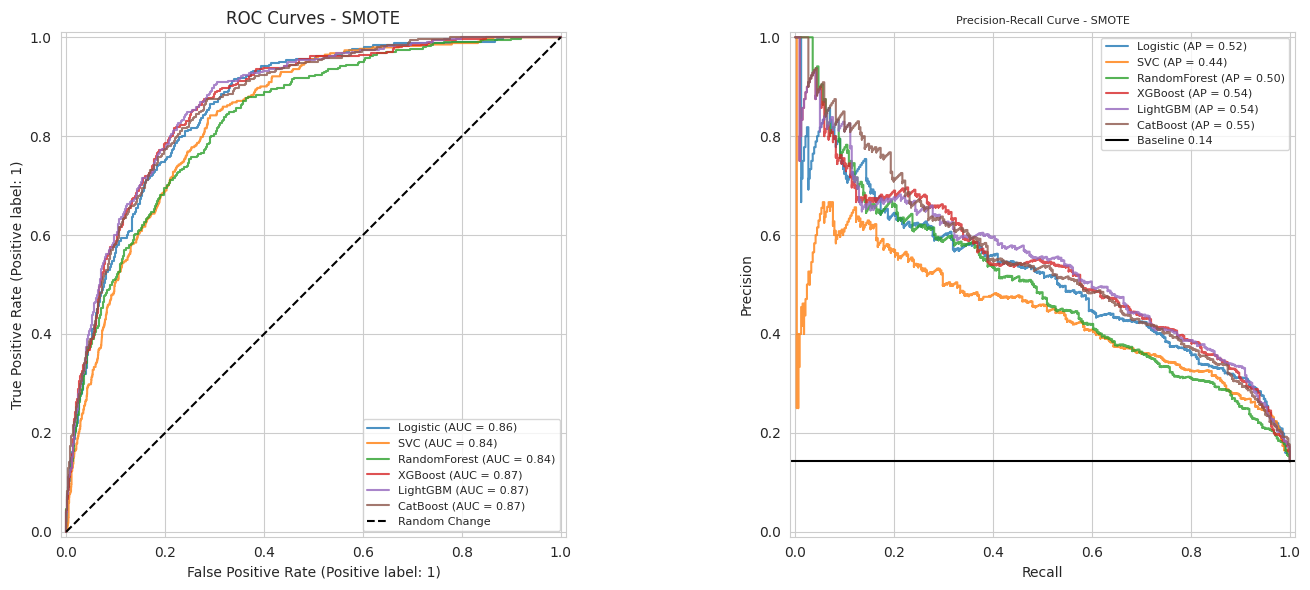

In [33]:
plot_model_comparison(predictions, 'SMOTE')

### models with SMOTE sample after hyperparameter tuning

In [34]:
param_grids = {
    'Logistic': {'C': [0.001, 0.01, 0.1], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
    'SVC': {'C': [1, 5, 10, 20], 'gamma': [0.0001, 0.001, 0.01], 'kernel': ['rbf']},
    'RandomForest': {'max_depth': [15, 25], 'min_samples_leaf': [2, 10], 'max_features': ['sqrt', 0.2], 'max_samples': [0.8, 0.9]},
    'XGBoost': {'max_depth': [6, 8, 10], 'min_child_weight': [2, 5, 10], 'gamma': [0.1, 0.2, 0.3], 'reg_alpha': [0.1, 0.5], 'reg_lambda': [1.0, 5.0, 10.0], 'subsample': [0.7, 0.8], 'colsample_bytree': [0.5, 0.6]},
    'LightGBM': {'num_leaves': [100, 127], 'min_child_samples': [40, 50, 70], 'min_split_gain': [0.1, 0.2, 0.3], 'reg_alpha': [0.05, 0.1], 'reg_lambda': [3.0, 5.0], 'subsample': [0.7, 0.8], 'colsample_bytree': [0.5, 0.6, 0.7]},
    'CatBoost': {'depth': [6, 8, 10], 'min_data_in_leaf': [10, 20, 50], 'l2_leaf_reg': [1, 5, 10], 'rsm': [0.3, 0.5, 0.7], 'random_strength': [1, 3, 5]}}

In [35]:
# models_smote = {
#     'Logistic': LogisticRegression(class_weight=None, C=0.01, penalty='l2', solver='lbfgs', max_iter=1000, random_state=SEED),    
#     'SVC': SVC(class_weight=None, C=1.0, kernel='rbf', gamma='scale', probability=True, cache_size=2000, random_state=SEED),
#     'RandomForest': RandomForestClassifier(class_weight=None, n_estimators=800, max_depth=15, min_samples_leaf=20, min_samples_split=2, bootstrap=True, max_features=0.3, max_samples=None, random_state=SEED, n_jobs=1),    
#     'XGBoost': XGBClassifier(objective='binary:logistic', eval_metric='logloss', tree_method='hist', scale_pos_weight=1, n_estimators=1500, learning_rate=0.02, max_depth=10, min_child_weight=5, gamma=0.2, reg_alpha=0.1, reg_lambda=5.0, subsample=0.7, colsample_bytree=0.6, colsample_bynode=0.8, random_state=SEED, n_jobs=1),
#     'LightGBM': LGBMClassifier(objective='binary', metric='binary_logloss', is_unbalance=False, n_estimators=1500, learning_rate=0.02, max_depth=10, num_leaves=127, min_child_samples=50, min_split_gain=0.2, reg_alpha=0.1, reg_lambda=5.0, subsample=0.7, subsample_freq=1, colsample_bytree=0.6, colsample_bynode=0.8, force_row_wise=True, max_bin=255, importance_type='gain', random_state=SEED, n_jobs=1, verbose=-1),
#     'CatBoost': CatBoostClassifier(loss_function='Logloss', eval_metric='Logloss', boosting_type='Plain', auto_class_weights=None, iterations=1500, learning_rate=0.02, depth=10, min_data_in_leaf=20, l2_leaf_reg=10.0, subsample=0.7, bootstrap_type='MVS', rsm=0.6, random_strength=3, random_seed=SEED, thread_count=1, verbose=0)}

In [36]:
# for name, model in models_smote.items():
#   if name in ['Logistic', 'SVC']:
#     best_model = tune_model(name, model, param_grids, X_linear_sm, y_linear_sm, search_type='random', cv=5, n_iter=15, scoring='average_precision')
#     best_models_smote[name] = best_model
#     evaluate_model(name, 'Tuned-SMOTE', best_model, X_linear_sm, X_test_linear, y_linear_sm, y_test, is_tuned=True)
#   else:
#     best_model = tune_model(name, model, param_grids, X_tree_sm, y_tree_sm, search_type='random', cv=5, n_iter=15, scoring='average_precision')
#     best_models_smote[name] = best_model
#     evaluate_model(name, 'Tuned-SMOTE', best_model, X_tree_sm, X_test_smote, y_tree_sm, y_test, is_tuned=True)

In [37]:
# svc_smote_imp = get_svc_importance(best_models_smote['SVC'], 'Tuned-SMOTE', X_test_linear, y_test)
# dfs_importance.append(svc_smote_imp)

In [38]:
best_model = tune_model('Logistic', LogisticRegression(class_weight=None, C=0.01, penalty='l2', solver='lbfgs', max_iter=1000, random_state=SEED), param_grids, X_linear_sm, y_linear_sm, search_type='grid', cv=5, scoring='average_precision')
best_models_smote['Logistic'] = best_model
evaluate_model('Logistic', 'Tuned-SMOTE', best_model, X_linear_sm, X_test_linear, y_linear_sm, y_test, is_tuned=True)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.3s
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.3s
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.3s
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.3s
[CV] END ..............C=0.001, penalty=l2, solver=liblinear; total time=   0.8s
[CV] END ..............C=0.001, penalty=l2, solver=liblinear; total time=   0.8s
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.6s
[CV] END ..............C=0.001, penalty=l2, solver=liblinear; total time=   1.1s
[CV] END ..............C=0.001, penalty=l2, solver=liblinear; total time=   1.2s
[CV] END ...............C=0.01, penalty=l1, solver=liblinear; total time=   0.9s
[CV] END ..............C=0.001, penalty=l2, solver=liblinear; total time=   1.3s
[CV] END ...............C=0.01, penalty=l1, solve

In [39]:
best_model = tune_model('SVC', SVC(class_weight=None, C=1.0, kernel='rbf', gamma='scale', probability=True, cache_size=2000, random_state=SEED), param_grids, X_linear_sm, y_linear_sm, search_type='grid', cv=5, scoring='average_precision')
best_models_smote['SVC'] = best_model
evaluate_model('SVC', 'Tuned-SMOTE', best_model, X_linear_sm, X_test_linear, y_linear_sm, y_test, is_tuned=True)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END .......................C=5, gamma=0.001, kernel=rbf; total time= 5.9min
[CV] END .......................C=5, gamma=0.001, kernel=rbf; total time= 6.5min
[CV] END .......................C=1, gamma=0.001, kernel=rbf; total time= 6.8min
[CV] END .......................C=1, gamma=0.001, kernel=rbf; total time= 7.0min
[CV] END .......................C=1, gamma=0.001, kernel=rbf; total time= 7.0min
[CV] END .......................C=1, gamma=0.001, kernel=rbf; total time= 7.1min
[CV] END ......................C=5, gamma=0.0001, kernel=rbf; total time= 7.3min
[CV] END ......................C=5, gamma=0.0001, kernel=rbf; total time= 7.4min
[CV] END .......................C=1, gamma=0.001, kernel=rbf; total time= 7.4min
[CV] END ........................C=1, gamma=0.01, kernel=rbf; total time= 7.6min
[CV] END ........................C=1, gamma=0.01, kernel=rbf; total time= 7.7min
[CV] END ......................C=5, gamma=0.0001

/home/leewen/code/physionet/.venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END ......................C=1, gamma=0.0001, kernel=rbf; total time= 9.5min
[CV] END .......................C=5, gamma=0.001, kernel=rbf; total time= 6.8min
[CV] END .......................C=5, gamma=0.001, kernel=rbf; total time= 6.0min
[CV] END .......................C=5, gamma=0.001, kernel=rbf; total time= 6.4min
[CV] END ......................C=10, gamma=0.001, kernel=rbf; total time= 6.3min
[CV] END ......................C=10, gamma=0.001, kernel=rbf; total time= 6.4min
[CV] END .....................C=10, gamma=0.0001, kernel=rbf; total time= 7.2min
[CV] END .....................C=10, gamma=0.0001, kernel=rbf; total time= 7.1min
[CV] END ........................C=5, gamma=0.01, kernel=rbf; total time= 7.9min
[CV] END ......................C=10, gamma=0.001, kernel=rbf; total time= 6.4min
[CV] END ......................C=10, gamma=0.001, kernel=rbf; total time= 6.4min
[CV] END ......................C=10, gamma=0.001, kernel=rbf; total time= 6.8min
[CV] END ...................

In [40]:
best_model = tune_model('RandomForest', RandomForestClassifier(class_weight=None, n_estimators=800, max_depth=15, min_samples_leaf=20, min_samples_split=2, bootstrap=True, max_features=0.3, max_samples=None, random_state=SEED, n_jobs=1), param_grids, X_tree_sm, y_tree_sm, search_type='random', cv=5, n_iter=15, scoring='average_precision')
best_models_smote['RandomForest'] = best_model
evaluate_model('RandomForest', 'Tuned-SMOTE', best_model, X_tree_sm, X_test_smote, y_tree_sm, y_test, is_tuned=True)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
[CV] END max_depth=15, max_features=sqrt, max_samples=0.8, min_samples_leaf=10; total time= 3.4min
[CV] END max_depth=15, max_features=sqrt, max_samples=0.8, min_samples_leaf=10; total time= 3.5min
[CV] END max_depth=15, max_features=sqrt, max_samples=0.8, min_samples_leaf=10; total time= 3.5min
[CV] END max_depth=15, max_features=sqrt, max_samples=0.8, min_samples_leaf=10; total time= 3.6min
[CV] END max_depth=15, max_features=sqrt, max_samples=0.8, min_samples_leaf=10; total time= 3.7min
[CV] END max_depth=15, max_features=sqrt, max_samples=0.8, min_samples_leaf=2; total time= 3.8min
[CV] END max_depth=15, max_features=sqrt, max_samples=0.8, min_samples_leaf=2; total time= 3.9min
[CV] END max_depth=15, max_features=sqrt, max_samples=0.8, min_samples_leaf=2; total time= 4.0min
[CV] END max_depth=15, max_features=sqrt, max_samples=0.8, min_samples_leaf=2; total time= 4.1min
[CV] END max_depth=15, max_features=sqrt, max_sample

In [41]:
best_model = tune_model('XGBoost', XGBClassifier(objective='binary:logistic', eval_metric='logloss', tree_method='hist', scale_pos_weight=1, n_estimators=1500, learning_rate=0.02, max_depth=10, min_child_weight=5, gamma=0.2, reg_alpha=0.1, reg_lambda=5.0, subsample=0.7, colsample_bytree=0.6, colsample_bynode=0.8, random_state=SEED, n_jobs=1), param_grids, X_tree_sm, y_tree_sm, search_type='random', cv=5, n_iter=20, scoring='average_precision')
best_models_smote['XGBoost'] = best_model
evaluate_model('XGBoost', 'Tuned-SMOTE', best_model, X_tree_sm, X_test_smote, y_tree_sm, y_test, is_tuned=True)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END colsample_bytree=0.5, gamma=0.3, max_depth=6, min_child_weight=2, reg_alpha=0.1, reg_lambda=10.0, subsample=0.7; total time= 1.6min
[CV] END colsample_bytree=0.6, gamma=0.1, max_depth=10, min_child_weight=10, reg_alpha=0.5, reg_lambda=5.0, subsample=0.8; total time= 1.6min
[CV] END colsample_bytree=0.5, gamma=0.3, max_depth=6, min_child_weight=2, reg_alpha=0.1, reg_lambda=10.0, subsample=0.7; total time= 1.9min
[CV] END colsample_bytree=0.6, gamma=0.3, max_depth=8, min_child_weight=5, reg_alpha=0.1, reg_lambda=10.0, subsample=0.8; total time= 2.0min
[CV] END colsample_bytree=0.5, gamma=0.3, max_depth=6, min_child_weight=2, reg_alpha=0.1, reg_lambda=10.0, subsample=0.7; total time= 2.1min
[CV] END colsample_bytree=0.5, gamma=0.1, max_depth=10, min_child_weight=2, reg_alpha=0.1, reg_lambda=1.0, subsample=0.7; total time= 2.1min
[CV] END colsample_bytree=0.5, gamma=0.3, max_depth=6, min_child_weight=2, reg_alpha=0.1, r

In [42]:
best_model = tune_model('LightGBM', LGBMClassifier(objective='binary', metric='binary_logloss', is_unbalance=False, n_estimators=1500, learning_rate=0.02, max_depth=10, num_leaves=127, min_child_samples=50, min_split_gain=0.2, reg_alpha=0.1, reg_lambda=5.0, subsample=0.7, subsample_freq=1, colsample_bytree=0.6, colsample_bynode=0.8, force_row_wise=True, max_bin=255, importance_type='gain', random_state=SEED, n_jobs=1, verbose=-1), param_grids, X_tree_sm, y_tree_sm, search_type='random', cv=5, n_iter=20, scoring='average_precision')
best_models_smote['LightGBM'] = best_model
evaluate_model('LightGBM', 'Tuned-SMOTE', best_model, X_tree_sm, X_test_smote, y_tree_sm, y_test, is_tuned=True)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END colsample_bytree=0.5, min_child_samples=50, min_split_gain=0.2, num_leaves=127, reg_alpha=0.05, reg_lambda=5.0, subsample=0.8; total time=  39.0s
[CV] END colsample_bytree=0.5, min_child_samples=40, min_split_gain=0.2, num_leaves=127, reg_alpha=0.1, reg_lambda=5.0, subsample=0.7; total time=  44.5s
[CV] END colsample_bytree=0.6, min_child_samples=40, min_split_gain=0.3, num_leaves=100, reg_alpha=0.1, reg_lambda=3.0, subsample=0.7; total time= 1.0min
[CV] END colsample_bytree=0.7, min_child_samples=70, min_split_gain=0.3, num_leaves=127, reg_alpha=0.05, reg_lambda=3.0, subsample=0.7; total time= 1.1min
[CV] END colsample_bytree=0.5, min_child_samples=40, min_split_gain=0.2, num_leaves=127, reg_alpha=0.1, reg_lambda=5.0, subsample=0.7; total time= 1.2min
[CV] END colsample_bytree=0.5, min_child_samples=40, min_split_gain=0.2, num_leaves=127, reg_alpha=0.1, reg_lambda=5.0, subsample=0.7; total time= 1.2min
[CV] END col

In [43]:
best_model = tune_model('CatBoost', CatBoostClassifier(loss_function='Logloss', eval_metric='Logloss', boosting_type='Plain', auto_class_weights=None, iterations=1500, learning_rate=0.02, depth=10, min_data_in_leaf=20, l2_leaf_reg=10.0, subsample=0.7, bootstrap_type='MVS', rsm=0.6, random_strength=3, random_seed=SEED, thread_count=1, verbose=0), param_grids, X_tree_sm, y_tree_sm, search_type='random', cv=5, n_iter=15, scoring='average_precision')
best_models_smote['CatBoost'] = best_model
evaluate_model('CatBoost', 'Tuned-SMOTE', best_model, X_tree_sm, X_test_smote, y_tree_sm, y_test, is_tuned=True)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
[CV] END depth=6, l2_leaf_reg=1, min_data_in_leaf=50, random_strength=5, rsm=0.3; total time= 2.0min


/home/leewen/code/physionet/.venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END depth=6, l2_leaf_reg=1, min_data_in_leaf=50, random_strength=5, rsm=0.3; total time= 2.0min
[CV] END depth=6, l2_leaf_reg=1, min_data_in_leaf=10, random_strength=5, rsm=0.3; total time= 2.0min
[CV] END depth=6, l2_leaf_reg=1, min_data_in_leaf=10, random_strength=5, rsm=0.3; total time= 2.0min
[CV] END depth=6, l2_leaf_reg=1, min_data_in_leaf=50, random_strength=5, rsm=0.3; total time= 2.0min
[CV] END depth=6, l2_leaf_reg=1, min_data_in_leaf=50, random_strength=5, rsm=0.3; total time= 2.0min
[CV] END depth=6, l2_leaf_reg=1, min_data_in_leaf=50, random_strength=5, rsm=0.3; total time= 2.1min
[CV] END depth=6, l2_leaf_reg=1, min_data_in_leaf=10, random_strength=5, rsm=0.3; total time= 2.1min
[CV] END depth=6, l2_leaf_reg=1, min_data_in_leaf=10, random_strength=5, rsm=0.3; total time= 2.1min
[CV] END depth=6, l2_leaf_reg=1, min_data_in_leaf=10, random_strength=5, rsm=0.3; total time= 2.1min
[CV] END depth=8, l2_leaf_reg=10, min_data_in_leaf=20, random_strength=5, rsm=0.7; total ti

In [44]:
svc_smote_imp = get_svc_importance(best_models_smote['SVC'], 'Tuned-SMOTE', X_test_linear, y_test)
dfs_importance.append(svc_smote_imp)

Calculating Permutation Importance for SVC (Tuned-SMOTE)...


In [45]:
for name, model in best_models_smote.items():
    print(f'--- {name} Best Parameters ---')
    params = model.get_params()
    
    for param, value in params.items():
        print(f'{param}: {value}')
    print('\n')

--- Logistic Best Parameters ---
C: 0.01
class_weight: None
dual: False
fit_intercept: True
intercept_scaling: 1
l1_ratio: None
max_iter: 1000
multi_class: deprecated
n_jobs: None
penalty: l2
random_state: 42
solver: liblinear
tol: 0.0001
verbose: 0
warm_start: False


--- SVC Best Parameters ---
C: 10
break_ties: False
cache_size: 2000
class_weight: None
coef0: 0.0
decision_function_shape: ovr
degree: 3
gamma: 0.01
kernel: rbf
max_iter: -1
probability: True
random_state: 42
shrinking: True
tol: 0.001
verbose: False


--- RandomForest Best Parameters ---
bootstrap: True
ccp_alpha: 0.0
class_weight: None
criterion: gini
max_depth: 25
max_features: sqrt
max_leaf_nodes: None
max_samples: 0.9
min_impurity_decrease: 0.0
min_samples_leaf: 2
min_samples_split: 2
min_weight_fraction_leaf: 0.0
monotonic_cst: None
n_estimators: 800
n_jobs: 1
oob_score: False
random_state: 42
verbose: 0
warm_start: False


--- XGBoost Best Parameters ---
objective: binary:logistic
base_score: None
booster: None
c

In [46]:
df_results = pd.DataFrame(results)
df_results

,Model,Strategy,ROC_AUC,PR_AUC,F1,Recall,Precision,Specificity,Accuracy,TP,TN,FP,FN
0,Logistic,SMOTE,0.863701,0.515067,0.508342,0.757310,0.382570,0.796693,0.791076,259,1638,418,83
1,SVC,SMOTE,0.839904,0.439331,0.476858,0.497076,0.458221,0.902237,0.844454,170,1855,201,172
2,RandomForest,SMOTE,0.835044,0.496076,0.490716,0.540936,0.449029,0.889591,0.839867,185,1829,227,157
3,XGBoost,SMOTE,0.869673,0.535876,0.446018,0.368421,0.565022,0.952821,0.869475,126,1959,97,216
4,LightGBM,SMOTE,0.873178,0.541951,0.465950,0.380117,0.601852,0.958171,0.875730,130,1970,86,212
5,CatBoost,SMOTE,0.867302,0.545888,0.458781,0.374269,0.592593,0.957198,0.874062,128,1968,88,214
6,Logistic,Tuned-SMOTE,0.863930,0.515502,0.507205,0.771930,0.377682,0.788424,0.786072,264,1621,435,78
7,SVC,Tuned-SMOTE,0.831021,0.421532,0.245536,0.160819,0.518868,0.975195,0.859049,55,2005,51,287
8,RandomForest,Tuned-SMOTE,0.841150,0.481220,0.467615,0.432749,0.508591,0.930447,0.859466,148,1913,143,194
9,XGBoost,Tuned-SMOTE,0.871137,0.541344,0.437956,0.350877,0.582524,0.958171,0.871560,120,1970,86,222



--- Plotting Curves for Strategy: Tuned-SMOTE ---



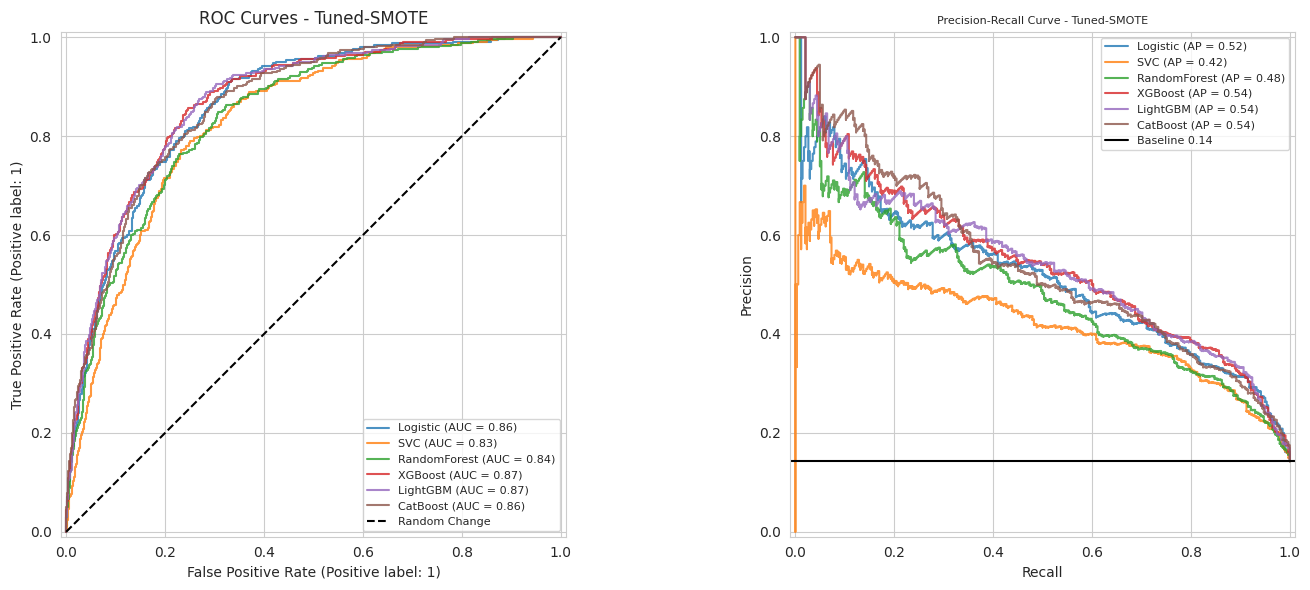

In [47]:
plot_model_comparison(predictions, 'Tuned-SMOTE')

### models with class weight adjustment

In [48]:
count_neg = (y_train == 0).sum()
count_pos = (y_train == 1).sum()
scale_weight = (count_neg / count_pos).item()

In [49]:
models_weight = {
    'Logistic': LogisticRegression(class_weight='balanced', C=0.01, penalty='l2', solver='lbfgs', max_iter=1000, random_state=SEED),    
    'SVC': SVC(class_weight='balanced', C=1.0, kernel='rbf', gamma='scale', probability=True, cache_size=2000, random_state=SEED),    
    'RandomForest': RandomForestClassifier(class_weight='balanced_subsample', n_estimators=800, max_depth=15, min_samples_leaf=20, min_samples_split=2, bootstrap=True, max_features=0.3, max_samples=None, random_state=SEED, n_jobs=-1),    
    'XGBoost': XGBClassifier(objective='binary:logistic', eval_metric='logloss', tree_method='hist', scale_pos_weight=scale_weight, n_estimators=1500, learning_rate=0.02, max_depth=10, min_child_weight=5, gamma=0.2, reg_alpha=0.1, reg_lambda=5.0, subsample=0.7, colsample_bytree=0.6, colsample_bynode=0.8, random_state=SEED, n_jobs=-1),
    'LightGBM': LGBMClassifier(objective='binary', metric='binary_logloss', is_unbalance=True, n_estimators=1500, learning_rate=0.02, max_depth=10, num_leaves=127, min_child_samples=50, min_split_gain=0.2, reg_alpha=0.1, reg_lambda=5.0, subsample=0.7, subsample_freq=1, colsample_bytree=0.6, colsample_bynode=0.8, force_row_wise=True, max_bin=255, importance_type='gain', random_state=SEED, n_jobs=-1, verbose=-1),
    'CatBoost': CatBoostClassifier(loss_function='Logloss', eval_metric='Logloss', boosting_type='Plain', auto_class_weights='Balanced', iterations=1500, learning_rate=0.02, depth=10, min_data_in_leaf=20, l2_leaf_reg=10.0, subsample=0.7, bootstrap_type='MVS', rsm=0.6, random_strength=3, random_seed=SEED, thread_count=-1, verbose=0)}

In [50]:
for name, model in models_weight.items():
  if name in ['Logistic', 'SVC']:
    evaluate_model(name, 'Weight', model, X_train_linear, X_test_linear, y_train, y_test)
  else:
    evaluate_model(name, 'Weight', model, X_train_tree, X_test_tree, y_train, y_test)

Fitting Logistic...
Output metrics for Logistic...
Output feature importance for Logistic...


Fitting SVC...
Output metrics for SVC...
Output feature importance for SVC...


Fitting RandomForest...
Output metrics for RandomForest...
Output feature importance for RandomForest...


Fitting XGBoost...
Output metrics for XGBoost...
Output feature importance for XGBoost...


Fitting LightGBM...
Output metrics for LightGBM...
Output feature importance for LightGBM...


Fitting CatBoost...
Output metrics for CatBoost...
Output feature importance for CatBoost...




In [51]:
svc_smote_imp = get_svc_importance(models_weight['SVC'], 'Weight', X_test_linear, y_test)
dfs_importance.append(svc_smote_imp)

Calculating Permutation Importance for SVC (Weight)...


In [52]:
df_results = pd.DataFrame(results)
df_results

,Model,Strategy,ROC_AUC,PR_AUC,F1,Recall,Precision,Specificity,Accuracy,TP,TN,FP,FN
0,Logistic,SMOTE,0.863701,0.515067,0.508342,0.757310,0.382570,0.796693,0.791076,259,1638,418,83
1,SVC,SMOTE,0.839904,0.439331,0.476858,0.497076,0.458221,0.902237,0.844454,170,1855,201,172
2,RandomForest,SMOTE,0.835044,0.496076,0.490716,0.540936,0.449029,0.889591,0.839867,185,1829,227,157
3,XGBoost,SMOTE,0.869673,0.535876,0.446018,0.368421,0.565022,0.952821,0.869475,126,1959,97,216
4,LightGBM,SMOTE,0.873178,0.541951,0.465950,0.380117,0.601852,0.958171,0.875730,130,1970,86,212
5,CatBoost,SMOTE,0.867302,0.545888,0.458781,0.374269,0.592593,0.957198,0.874062,128,1968,88,214
6,Logistic,Tuned-SMOTE,0.863930,0.515502,0.507205,0.771930,0.377682,0.788424,0.786072,264,1621,435,78
7,SVC,Tuned-SMOTE,0.831021,0.421532,0.245536,0.160819,0.518868,0.975195,0.859049,55,2005,51,287
8,RandomForest,Tuned-SMOTE,0.841150,0.481220,0.467615,0.432749,0.508591,0.930447,0.859466,148,1913,143,194
9,XGBoost,Tuned-SMOTE,0.871137,0.541344,0.437956,0.350877,0.582524,0.958171,0.871560,120,1970,86,222



--- Plotting Curves for Strategy: Weight ---



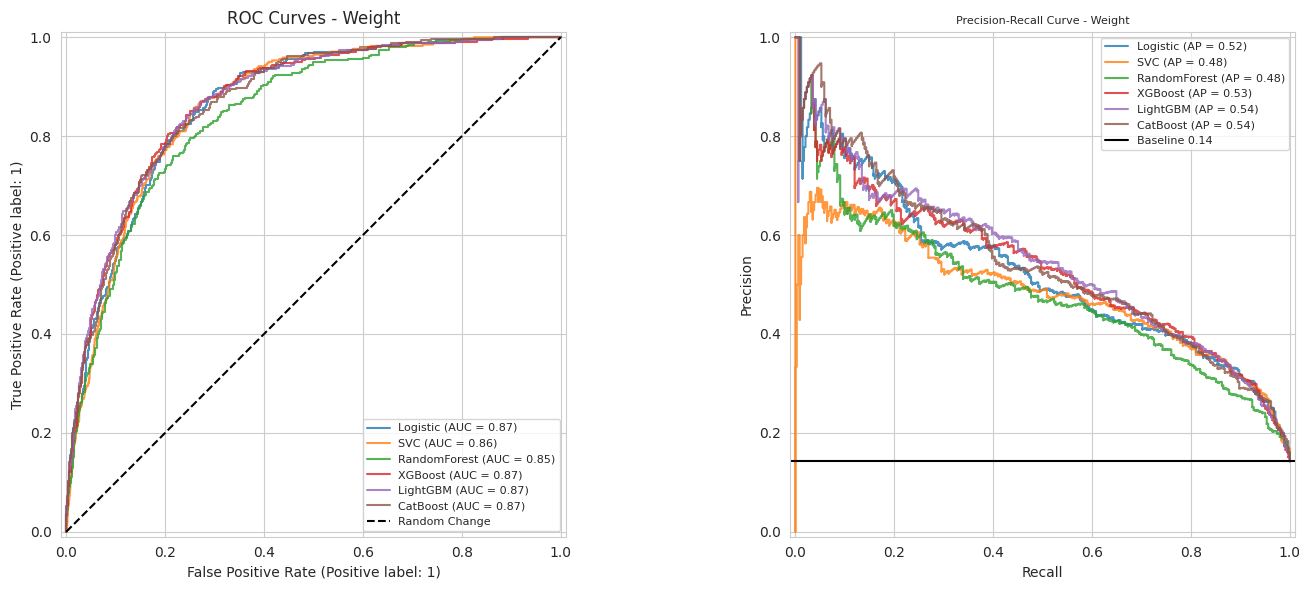

In [53]:
plot_model_comparison(predictions, 'Weight')

### models with class weight adjustment after hyperparameter tuning

In [54]:
param_grids = {
    'Logistic': {'C': [0.001, 0.01, 0.1], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
    'SVC': {'C': [1, 5, 10, 20], 'gamma': [0.0001, 0.001, 0.01], 'kernel': ['rbf']},
    'RandomForest': {'max_depth': [15, 25], 'min_samples_leaf': [2, 10], 'max_features': ['sqrt', 0.2], 'max_samples': [0.8, 0.9]},
    'XGBoost': {'max_depth': [6, 8, 10], 'min_child_weight': [2, 5, 10], 'gamma': [0.1, 0.2, 0.3], 'reg_alpha': [0.1, 0.5], 'reg_lambda': [1.0, 5.0, 10.0], 'subsample': [0.7, 0.8], 'colsample_bytree': [0.5, 0.6]},
    'LightGBM': {'num_leaves': [100, 127], 'min_child_samples': [40, 50, 70], 'min_split_gain': [0.1, 0.2, 0.3], 'reg_alpha': [0.05, 0.1], 'reg_lambda': [3.0, 5.0], 'subsample': [0.7, 0.8], 'colsample_bytree': [0.5, 0.6, 0.7]},
    'CatBoost': {'depth': [6, 8, 10], 'min_data_in_leaf': [10, 20, 50], 'l2_leaf_reg': [1, 5, 10], 'rsm': [0.3, 0.5, 0.7], 'random_strength': [1, 3, 5]}}

In [55]:
# models_weight = {
#     'Logistic': LogisticRegression(class_weight='balanced', C=0.01, penalty='l2', solver='lbfgs', max_iter=1000, random_state=SEED),    
#     'SVC': SVC(class_weight='balanced', C=1.0, kernel='rbf', gamma='scale', probability=True, cache_size=2000, random_state=SEED),    
#     'RandomForest': RandomForestClassifier(class_weight='balanced_subsample', n_estimators=800, max_depth=15, min_samples_leaf=20, min_samples_split=2, bootstrap=True, max_features=0.3, max_samples=None, random_state=SEED, n_jobs=1),    
#     'XGBoost': XGBClassifier(objective='binary:logistic', eval_metric='logloss', tree_method='hist', scale_pos_weight=scale_weight, n_estimators=1500, learning_rate=0.02, max_depth=10, min_child_weight=5, gamma=0.2, reg_alpha=0.1, reg_lambda=5.0, subsample=0.7, colsample_bytree=0.6, colsample_bynode=0.8, random_state=SEED, n_jobs=1),
#     'LightGBM': LGBMClassifier(objective='binary', metric='binary_logloss', is_unbalance=True, n_estimators=1500, learning_rate=0.02, max_depth=10, num_leaves=127, min_child_samples=50, min_split_gain=0.2, reg_alpha=0.1, reg_lambda=5.0, subsample=0.7, subsample_freq=1, colsample_bytree=0.6, colsample_bynode=0.8, force_row_wise=True, max_bin=255, importance_type='gain', random_state=SEED, n_jobs=1, verbose=-1),
#     'CatBoost': CatBoostClassifier(loss_function='Logloss', eval_metric='Logloss', boosting_type='Plain', auto_class_weights='Balanced', iterations=1500, learning_rate=0.02, depth=10, min_data_in_leaf=20, l2_leaf_reg=10.0, subsample=0.7, bootstrap_type='MVS', rsm=0.6, random_strength=3, random_seed=SEED, thread_count=1, verbose=0)}

In [56]:
# for name, model in models_weight.items():
#   if name in ['Logistic', 'SVC']:
#     best_model = tune_model(name, model, param_grids, X_train_linear, y_train, search_type='random', cv=5, n_iter=15, scoring='average_precision')
#     best_models_weight[name] = best_model
#     evaluate_model(name, 'Tuned-Weight', best_model, X_train_linear, X_test_linear, y_train, y_test, is_tuned=True)
#   else:
#     best_model = tune_model(name, model, param_grids, X_train_tree, y_train, search_type='random', cv=5, n_iter=15, scoring='average_precision')
#     best_models_weight[name] = best_model
#     evaluate_model(name, 'Tuned-Weight', best_model, X_train_tree, X_test_tree, y_train, y_test, is_tuned=True)

In [57]:
# svc_smote_imp = get_svc_importance(best_models_weight['SVC'], 'Tuned-Weight', X_test_linear, y_test)
# dfs_importance.append(svc_smote_imp)

In [58]:
best_model = tune_model('Logistic', LogisticRegression(class_weight='balanced', C=0.01, penalty='l2', solver='lbfgs', max_iter=1000, random_state=SEED), param_grids, X_train_linear, y_train, search_type='grid', cv=5, scoring='average_precision')
best_models_weight['Logistic'] = best_model
evaluate_model('Logistic', 'Tuned-Weight', best_model, X_train_linear, X_test_linear, y_train, y_test, is_tuned=True)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.2s
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.2s
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.2s
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.2s
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.2s
[CV] END ...............C=0.01, penalty=l1, solver=liblinear; total time=   0.4s
[CV] END ..............C=0.001, penalty=l2, solver=liblinear; total time=   0.5s
[CV] END ..............C=0.001, penalty=l2, solver=liblinear; total time=   0.6s
[CV] END ...............C=0.01, penalty=l1, solver=liblinear; total time=   0.6s
[CV] END ...............C=0.01, penalty=l1, solver=liblinear; total time=   0.7s
[CV] END ..............C=0.001, penalty=l2, solver=liblinear; total time=   0.7s
[CV] END ...............C=0.01, penalty=l1, solve

In [59]:
best_model = tune_model('SVC', SVC(class_weight='balanced', C=1.0, kernel='rbf', gamma='scale', probability=True, cache_size=2000, random_state=SEED), param_grids, X_train_linear, y_train, search_type='grid', cv=5, scoring='average_precision')
best_models_weight['SVC'] = best_model
evaluate_model('SVC', 'Tuned-Weight', best_model, X_train_linear, X_test_linear, y_train, y_test, is_tuned=True)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END .......................C=5, gamma=0.001, kernel=rbf; total time= 2.3min
[CV] END ......................C=5, gamma=0.0001, kernel=rbf; total time= 2.6min
[CV] END .......................C=5, gamma=0.001, kernel=rbf; total time= 2.6min
[CV] END .......................C=1, gamma=0.001, kernel=rbf; total time= 2.7min
[CV] END ......................C=5, gamma=0.0001, kernel=rbf; total time= 2.8min
[CV] END .......................C=1, gamma=0.001, kernel=rbf; total time= 2.9min
[CV] END ......................C=5, gamma=0.0001, kernel=rbf; total time= 2.9min
[CV] END .......................C=1, gamma=0.001, kernel=rbf; total time= 2.9min
[CV] END .......................C=1, gamma=0.001, kernel=rbf; total time= 2.9min
[CV] END ......................C=5, gamma=0.0001, kernel=rbf; total time= 3.0min
[CV] END ........................C=1, gamma=0.01, kernel=rbf; total time= 3.0min
[CV] END .......................C=1, gamma=0.001

In [60]:
best_model = tune_model('RandomForest', RandomForestClassifier(class_weight='balanced_subsample', n_estimators=800, max_depth=15, min_samples_leaf=20, min_samples_split=2, bootstrap=True, max_features=0.3, max_samples=None, random_state=SEED, n_jobs=1), param_grids, X_train_tree, y_train, search_type='random', cv=5, n_iter=15, scoring='average_precision')
best_models_weight['RandomForest'] = best_model
evaluate_model('RandomForest', 'Tuned-Weight', best_model, X_train_tree, X_test_tree, y_train, y_test, is_tuned=True)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
[CV] END max_depth=15, max_features=sqrt, max_samples=0.8, min_samples_leaf=10; total time=  58.0s
[CV] END max_depth=15, max_features=sqrt, max_samples=0.8, min_samples_leaf=10; total time= 1.0min
[CV] END max_depth=15, max_features=sqrt, max_samples=0.8, min_samples_leaf=10; total time= 1.1min
[CV] END max_depth=15, max_features=sqrt, max_samples=0.8, min_samples_leaf=10; total time= 1.1min
[CV] END max_depth=15, max_features=sqrt, max_samples=0.8, min_samples_leaf=10; total time= 1.1min
[CV] END max_depth=15, max_features=sqrt, max_samples=0.8, min_samples_leaf=2; total time= 1.3min
[CV] END max_depth=15, max_features=sqrt, max_samples=0.8, min_samples_leaf=2; total time= 1.4min
[CV] END max_depth=15, max_features=sqrt, max_samples=0.8, min_samples_leaf=2; total time= 1.4min
[CV] END max_depth=15, max_features=sqrt, max_samples=0.8, min_samples_leaf=2; total time= 1.5min
[CV] END max_depth=15, max_features=sqrt, max_sample

In [61]:
best_model = tune_model('XGBoost', XGBClassifier(objective='binary:logistic', eval_metric='logloss', tree_method='hist', scale_pos_weight=scale_weight, n_estimators=1500, learning_rate=0.02, max_depth=10, min_child_weight=5, gamma=0.2, reg_alpha=0.1, reg_lambda=5.0, subsample=0.7, colsample_bytree=0.6, colsample_bynode=0.8, random_state=SEED, n_jobs=1), param_grids, X_train_tree, y_train, search_type='random', cv=5, n_iter=20, scoring='average_precision')
best_models_weight['XGBoost'] = best_model
evaluate_model('XGBoost', 'Tuned-Weight', best_model, X_train_tree, X_test_tree, y_train, y_test, is_tuned=True)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END colsample_bytree=0.5, gamma=0.3, max_depth=6, min_child_weight=2, reg_alpha=0.1, reg_lambda=10.0, subsample=0.7; total time= 1.1min
[CV] END colsample_bytree=0.5, gamma=0.3, max_depth=6, min_child_weight=2, reg_alpha=0.1, reg_lambda=10.0, subsample=0.7; total time= 1.2min
[CV] END colsample_bytree=0.5, gamma=0.3, max_depth=6, min_child_weight=2, reg_alpha=0.1, reg_lambda=10.0, subsample=0.7; total time= 1.2min
[CV] END colsample_bytree=0.5, gamma=0.3, max_depth=6, min_child_weight=2, reg_alpha=0.1, reg_lambda=10.0, subsample=0.7; total time= 1.2min
[CV] END colsample_bytree=0.5, gamma=0.3, max_depth=6, min_child_weight=2, reg_alpha=0.1, reg_lambda=10.0, subsample=0.7; total time= 1.2min
[CV] END colsample_bytree=0.6, gamma=0.3, max_depth=8, min_child_weight=5, reg_alpha=0.1, reg_lambda=10.0, subsample=0.8; total time= 1.5min
[CV] END colsample_bytree=0.6, gamma=0.1, max_depth=10, min_child_weight=10, reg_alpha=0.5, 

In [62]:
best_model = tune_model('LightGBM', LGBMClassifier(objective='binary', metric='binary_logloss', is_unbalance=True, n_estimators=1500, learning_rate=0.02, max_depth=10, num_leaves=127, min_child_samples=50, min_split_gain=0.2, reg_alpha=0.1, reg_lambda=5.0, subsample=0.7, subsample_freq=1, colsample_bytree=0.6, colsample_bynode=0.8, force_row_wise=True, max_bin=255, importance_type='gain', random_state=SEED, n_jobs=1, verbose=-1), param_grids, X_train_tree, y_train, search_type='random', cv=5, n_iter=20, scoring='average_precision')
best_models_weight['LightGBM'] = best_model
evaluate_model('LightGBM', 'Tuned-Weight', best_model, X_train_tree, X_test_tree, y_train, y_test, is_tuned=True)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END colsample_bytree=0.5, min_child_samples=40, min_split_gain=0.2, num_leaves=127, reg_alpha=0.1, reg_lambda=5.0, subsample=0.7; total time=  57.6s
[CV] END colsample_bytree=0.5, min_child_samples=50, min_split_gain=0.2, num_leaves=127, reg_alpha=0.05, reg_lambda=5.0, subsample=0.8; total time=  58.6s
[CV] END colsample_bytree=0.5, min_child_samples=50, min_split_gain=0.2, num_leaves=127, reg_alpha=0.05, reg_lambda=5.0, subsample=0.8; total time= 1.0min
[CV] END colsample_bytree=0.5, min_child_samples=50, min_split_gain=0.2, num_leaves=127, reg_alpha=0.05, reg_lambda=5.0, subsample=0.8; total time= 1.0min
[CV] END colsample_bytree=0.5, min_child_samples=40, min_split_gain=0.2, num_leaves=127, reg_alpha=0.1, reg_lambda=5.0, subsample=0.7; total time= 1.0min
[CV] END colsample_bytree=0.7, min_child_samples=70, min_split_gain=0.3, num_leaves=127, reg_alpha=0.05, reg_lambda=3.0, subsample=0.7; total time= 1.0min
[CV] END c

In [63]:
best_model = tune_model('CatBoost', CatBoostClassifier(loss_function='Logloss', eval_metric='Logloss', boosting_type='Plain', auto_class_weights='Balanced', iterations=1500, learning_rate=0.02, depth=10, min_data_in_leaf=20, l2_leaf_reg=10.0, subsample=0.7, bootstrap_type='MVS', rsm=0.6, random_strength=3, random_seed=SEED, thread_count=1, verbose=0), param_grids, X_train_tree, y_train, search_type='random', cv=5, n_iter=15, scoring='average_precision')
best_models_weight['CatBoost'] = best_model
evaluate_model('CatBoost', 'Tuned-Weight', best_model, X_train_tree, X_test_tree, y_train, y_test, is_tuned=True)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
[CV] END depth=6, l2_leaf_reg=1, min_data_in_leaf=10, random_strength=5, rsm=0.3; total time= 1.3min


/home/leewen/code/physionet/.venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END depth=6, l2_leaf_reg=1, min_data_in_leaf=10, random_strength=5, rsm=0.3; total time= 1.4min
[CV] END depth=6, l2_leaf_reg=1, min_data_in_leaf=10, random_strength=5, rsm=0.3; total time= 1.4min
[CV] END depth=6, l2_leaf_reg=1, min_data_in_leaf=50, random_strength=5, rsm=0.3; total time= 1.4min
[CV] END depth=6, l2_leaf_reg=1, min_data_in_leaf=50, random_strength=5, rsm=0.3; total time= 1.4min
[CV] END depth=6, l2_leaf_reg=1, min_data_in_leaf=10, random_strength=5, rsm=0.3; total time= 1.4min
[CV] END depth=6, l2_leaf_reg=1, min_data_in_leaf=50, random_strength=5, rsm=0.3; total time= 1.4min
[CV] END depth=6, l2_leaf_reg=1, min_data_in_leaf=50, random_strength=5, rsm=0.3; total time= 1.5min
[CV] END depth=6, l2_leaf_reg=1, min_data_in_leaf=10, random_strength=5, rsm=0.3; total time= 1.5min
[CV] END depth=6, l2_leaf_reg=1, min_data_in_leaf=50, random_strength=5, rsm=0.3; total time= 1.5min
[CV] END depth=8, l2_leaf_reg=10, min_data_in_leaf=20, random_strength=5, rsm=0.7; total ti

In [64]:
svc_smote_imp = get_svc_importance(best_models_weight['SVC'], 'Tuned-Weight', X_test_linear, y_test)
dfs_importance.append(svc_smote_imp)

Calculating Permutation Importance for SVC (Tuned-Weight)...


In [65]:
for name, model in best_models_weight.items():
    print(f'--- {name} Best Parameters ---')
    params = model.get_params()
    
    for param, value in params.items():
        print(f'{param}: {value}')
    print('\n')

--- Logistic Best Parameters ---
C: 0.1
class_weight: balanced
dual: False
fit_intercept: True
intercept_scaling: 1
l1_ratio: None
max_iter: 1000
multi_class: deprecated
n_jobs: None
penalty: l1
random_state: 42
solver: liblinear
tol: 0.0001
verbose: 0
warm_start: False


--- SVC Best Parameters ---
C: 20
break_ties: False
cache_size: 2000
class_weight: balanced
coef0: 0.0
decision_function_shape: ovr
degree: 3
gamma: 0.0001
kernel: rbf
max_iter: -1
probability: True
random_state: 42
shrinking: True
tol: 0.001
verbose: False


--- RandomForest Best Parameters ---
bootstrap: True
ccp_alpha: 0.0
class_weight: balanced_subsample
criterion: gini
max_depth: 25
max_features: 0.2
max_leaf_nodes: None
max_samples: 0.9
min_impurity_decrease: 0.0
min_samples_leaf: 10
min_samples_split: 2
min_weight_fraction_leaf: 0.0
monotonic_cst: None
n_estimators: 800
n_jobs: 1
oob_score: False
random_state: 42
verbose: 0
warm_start: False


--- XGBoost Best Parameters ---
objective: binary:logistic
base_scor

In [66]:
df_results = pd.DataFrame(results)
df_results

,Model,Strategy,ROC_AUC,PR_AUC,F1,Recall,Precision,Specificity,Accuracy,TP,TN,FP,FN
0,Logistic,SMOTE,0.863701,0.515067,0.508342,0.757310,0.382570,0.796693,0.791076,259,1638,418,83
1,SVC,SMOTE,0.839904,0.439331,0.476858,0.497076,0.458221,0.902237,0.844454,170,1855,201,172
2,RandomForest,SMOTE,0.835044,0.496076,0.490716,0.540936,0.449029,0.889591,0.839867,185,1829,227,157
3,XGBoost,SMOTE,0.869673,0.535876,0.446018,0.368421,0.565022,0.952821,0.869475,126,1959,97,216
4,LightGBM,SMOTE,0.873178,0.541951,0.465950,0.380117,0.601852,0.958171,0.875730,130,1970,86,212
5,CatBoost,SMOTE,0.867302,0.545888,0.458781,0.374269,0.592593,0.957198,0.874062,128,1968,88,214
6,Logistic,Tuned-SMOTE,0.863930,0.515502,0.507205,0.771930,0.377682,0.788424,0.786072,264,1621,435,78
7,SVC,Tuned-SMOTE,0.831021,0.421532,0.245536,0.160819,0.518868,0.975195,0.859049,55,2005,51,287
8,RandomForest,Tuned-SMOTE,0.841150,0.481220,0.467615,0.432749,0.508591,0.930447,0.859466,148,1913,143,194
9,XGBoost,Tuned-SMOTE,0.871137,0.541344,0.437956,0.350877,0.582524,0.958171,0.871560,120,1970,86,222



--- Plotting Curves for Strategy: Tuned-Weight ---



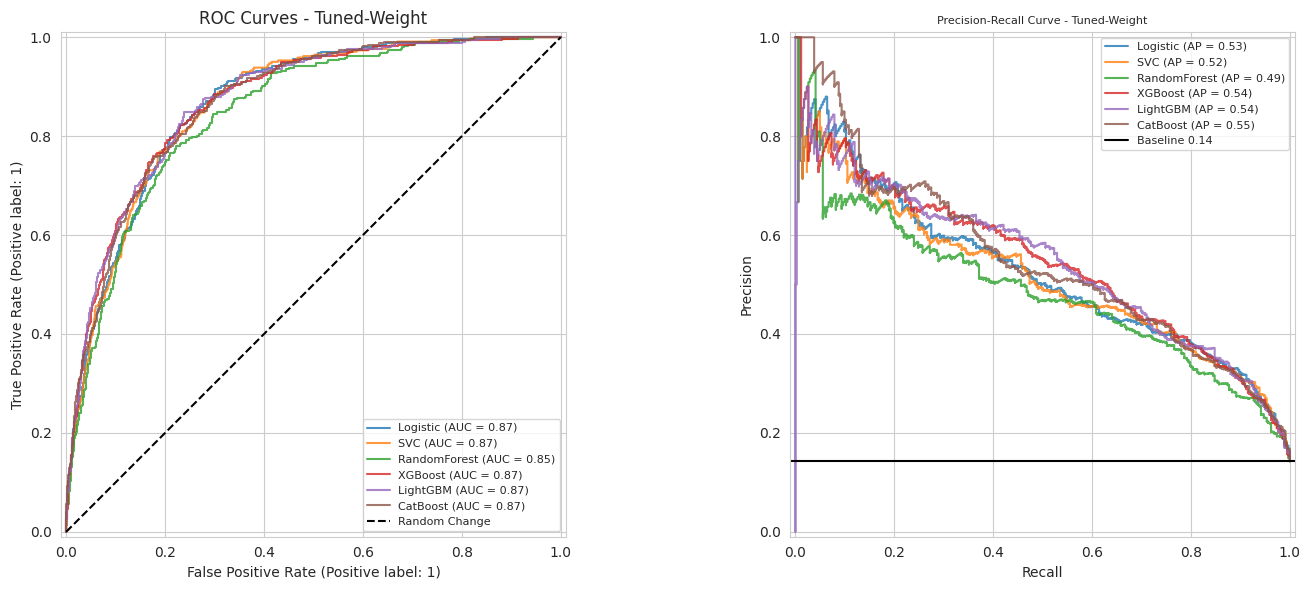

In [67]:
plot_model_comparison(predictions, 'Tuned-Weight')

# feature importance

In [68]:
df_all_importance = pd.concat(dfs_importance).reset_index(drop=True)

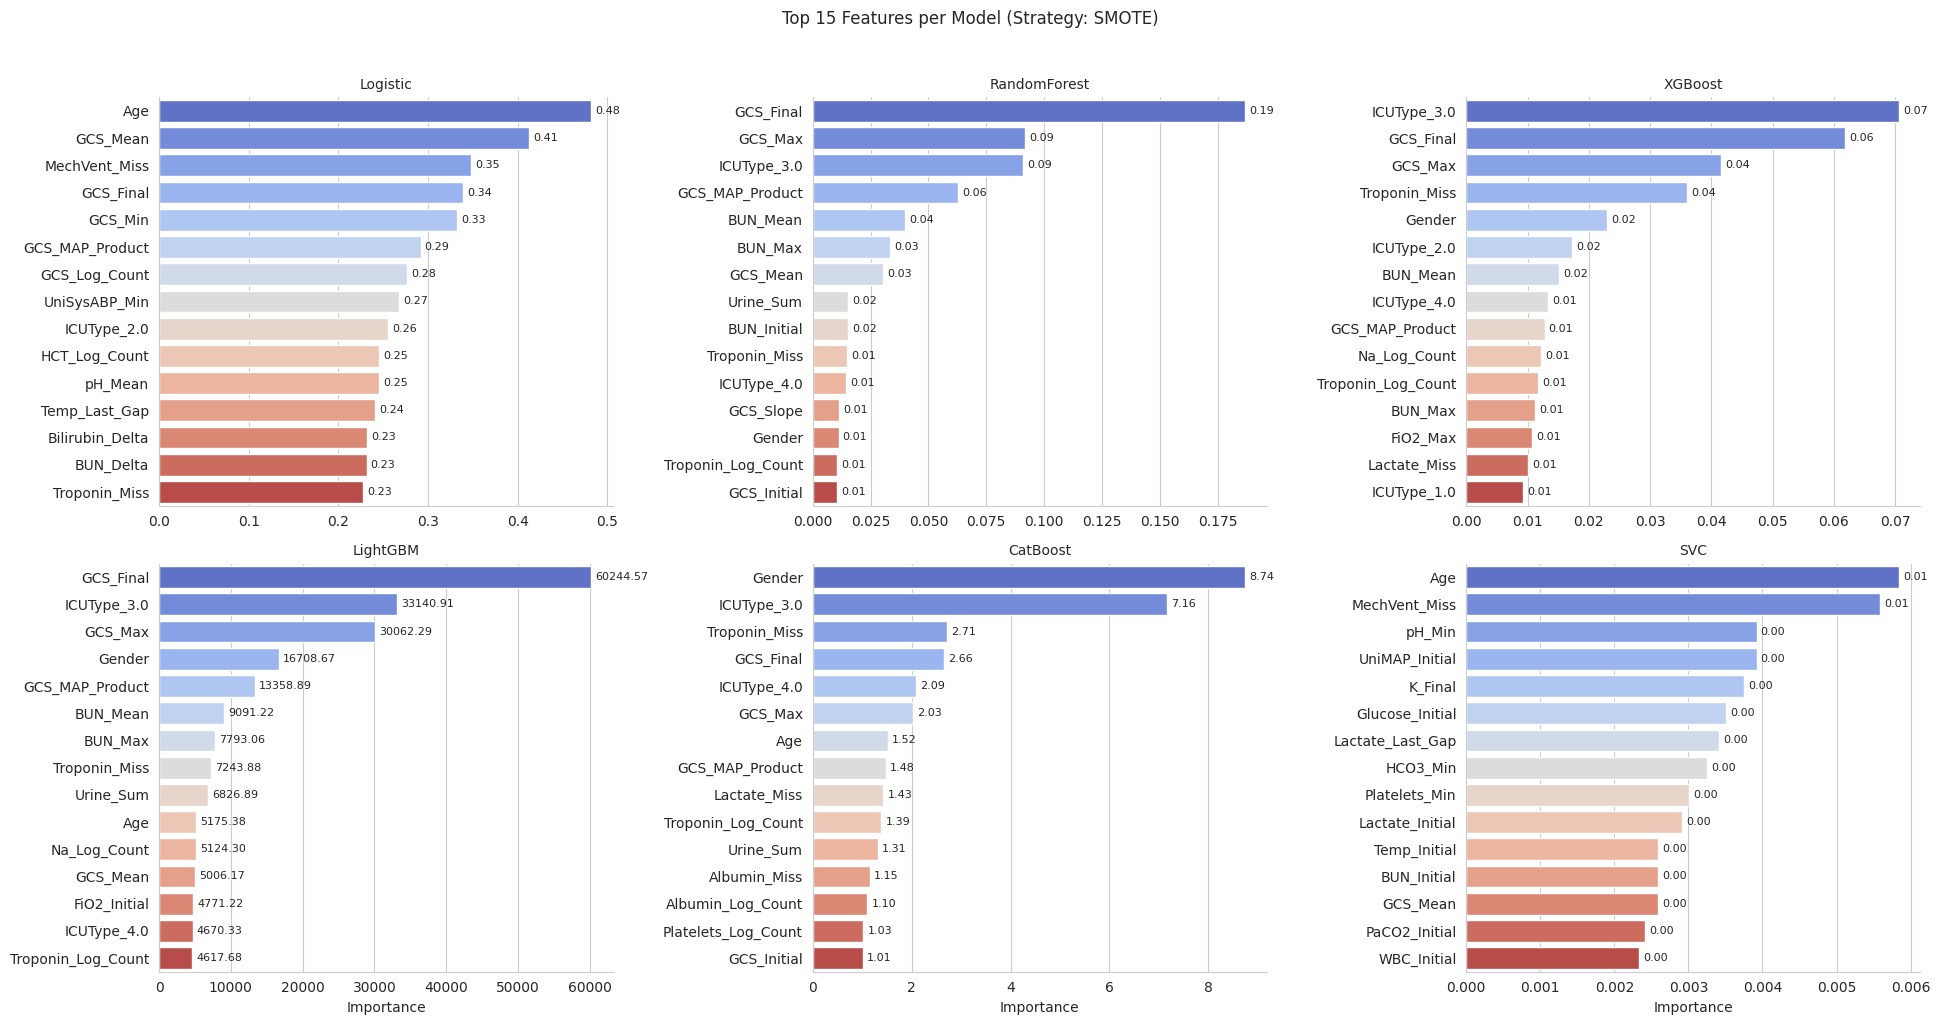

In [69]:
plot_feature_comparison(df_all_importance, 'SMOTE', top_n=15)

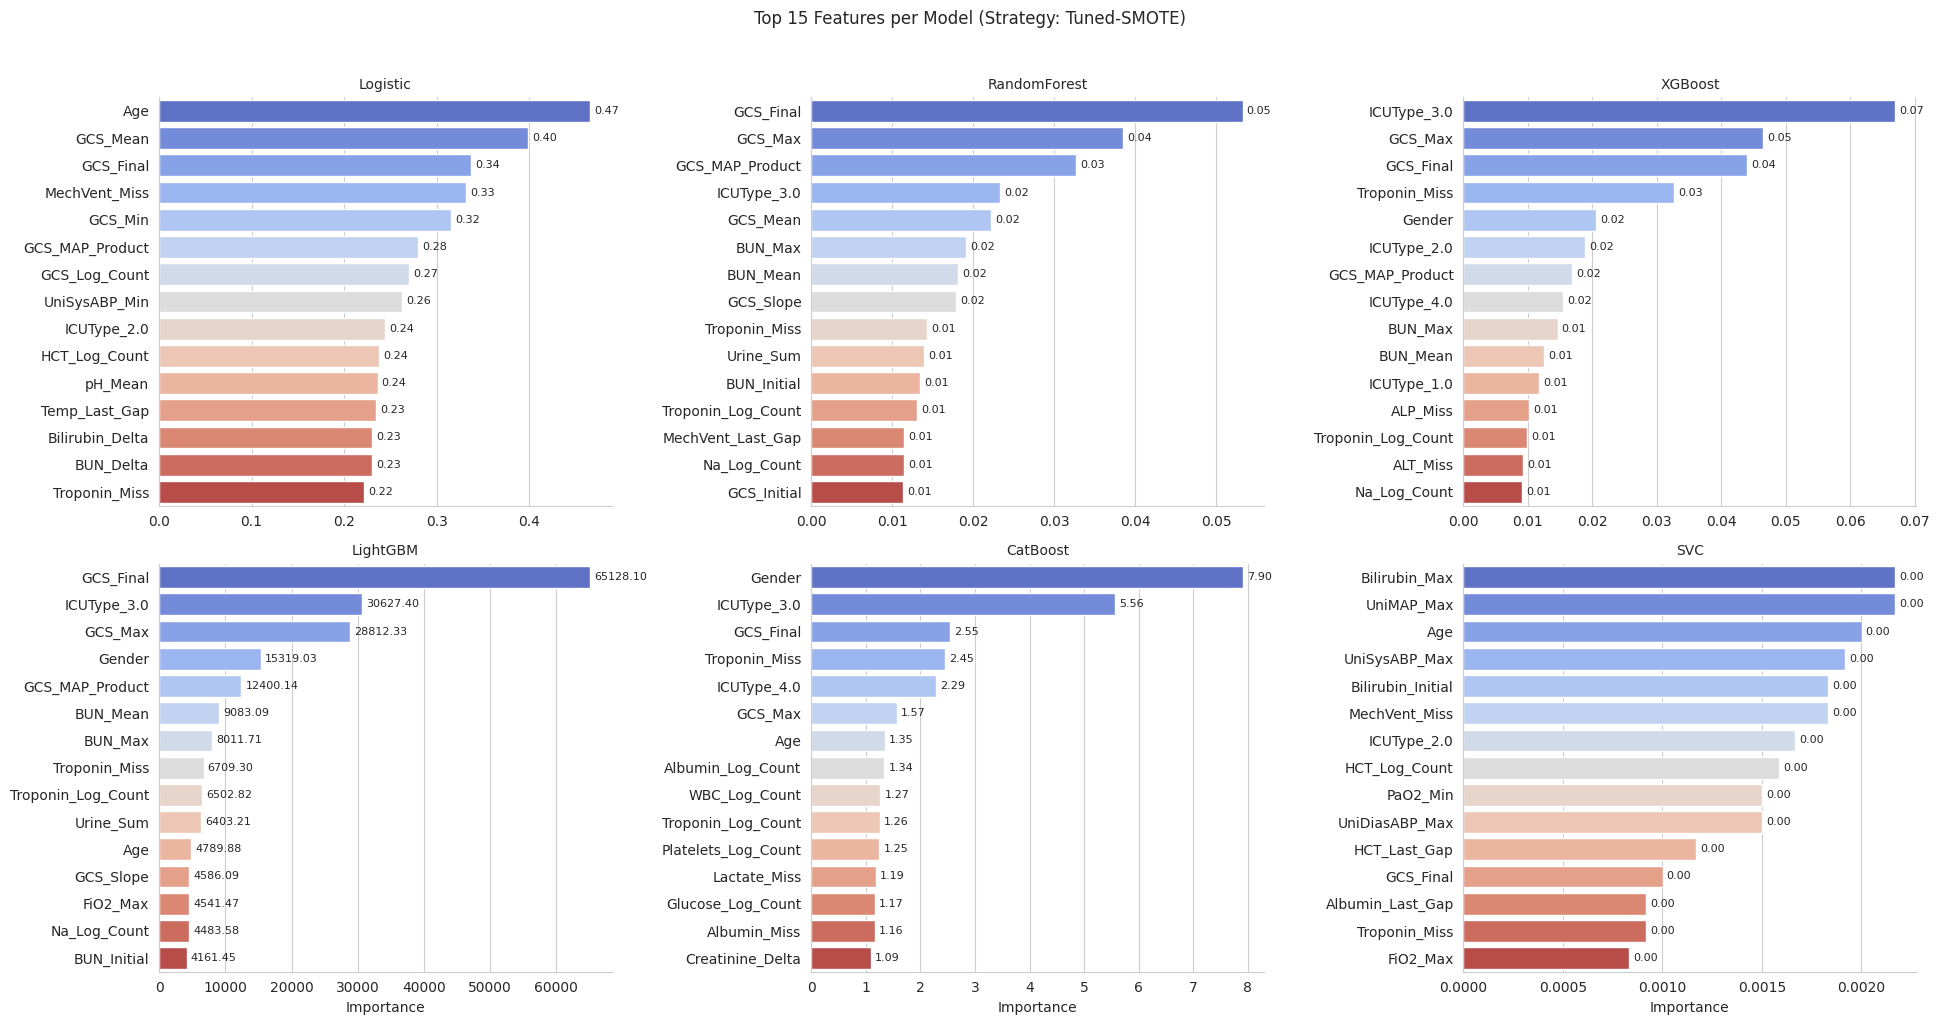

In [70]:
plot_feature_comparison(df_all_importance, 'Tuned-SMOTE', top_n=15)

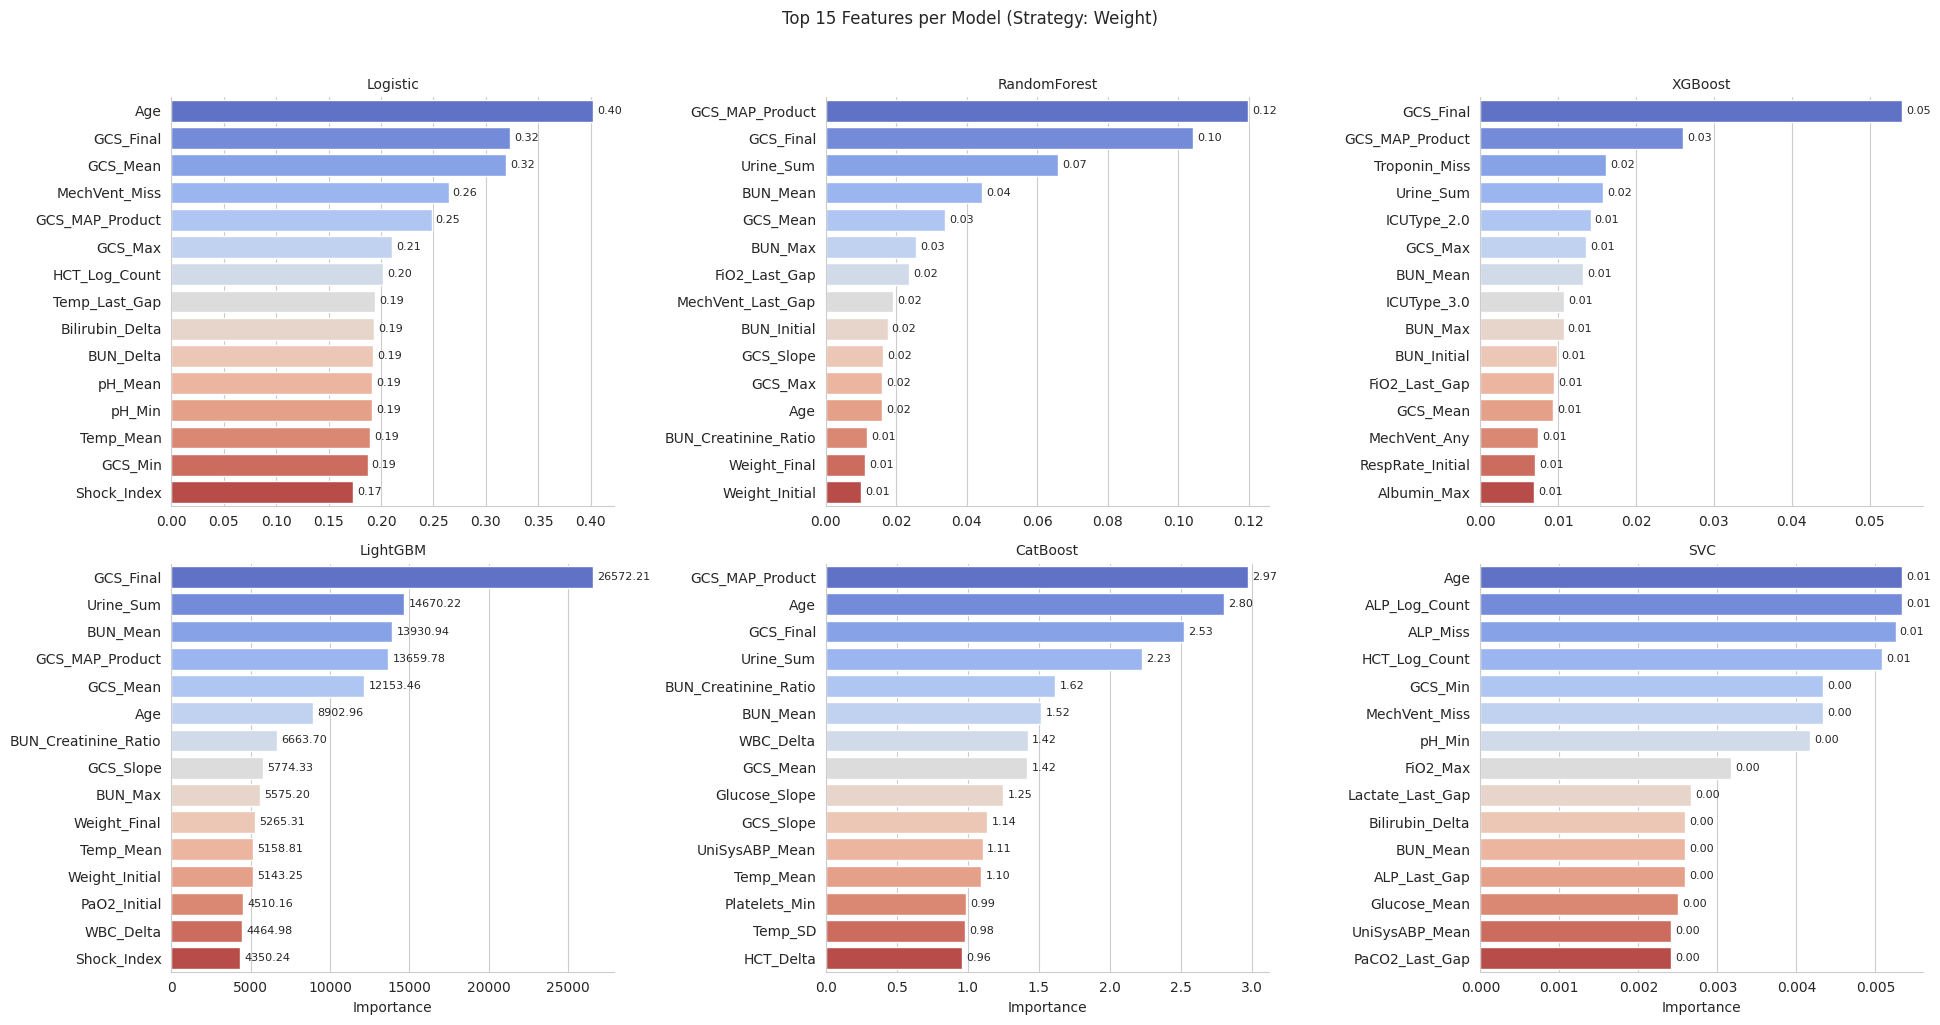

In [71]:
plot_feature_comparison(df_all_importance, 'Weight', top_n=15)

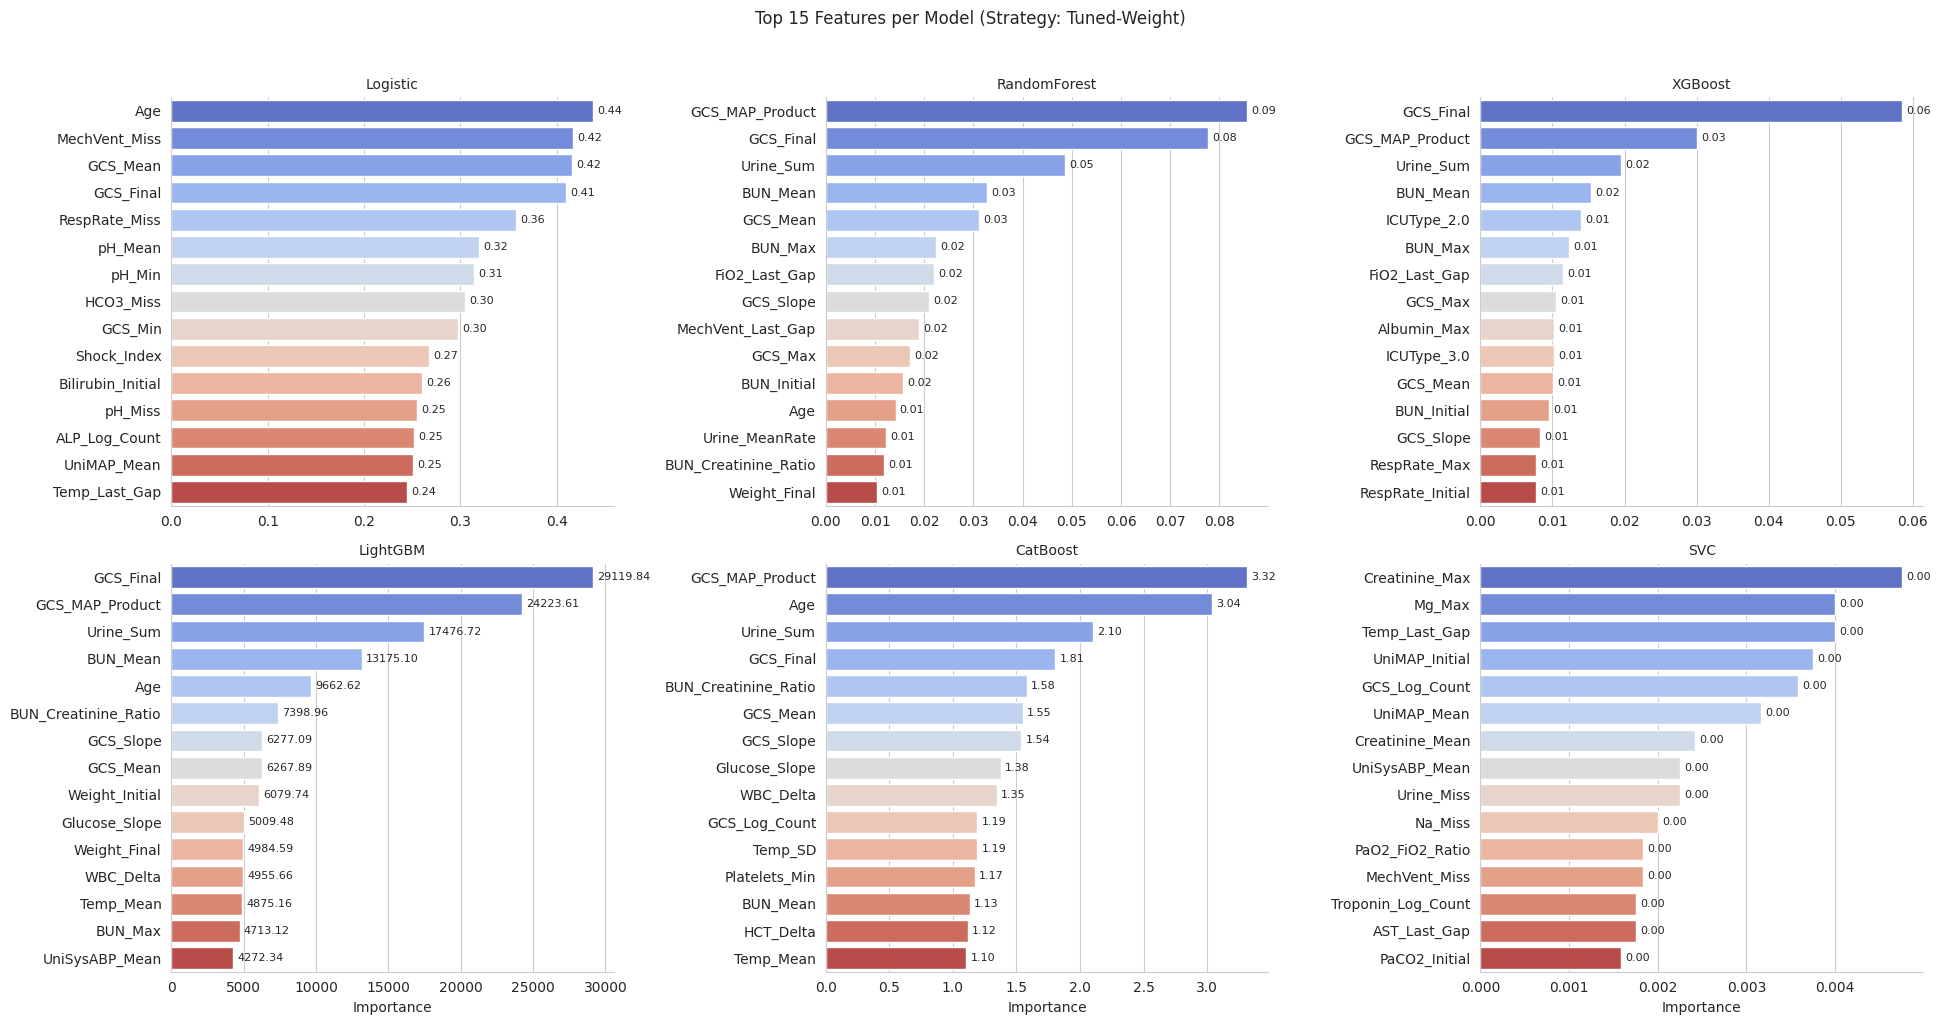

In [72]:
plot_feature_comparison(df_all_importance, 'Tuned-Weight', top_n=15)

# feature selection

### protected features

In [73]:
#X_train_tree.columns.to_list()

In [74]:
#X_train_linear.columns.to_list()

In [75]:
protected_features = ['Age', 'GCS_Min', 'Lactate_Max', 'Urine_Sum', 'Creatinine_Max','Shock_Index', 'UniMAP_Min', 'PaO2_FiO2_Ratio', 'Anion_Gap', 'pH_Min', 'MechVent_Any', 'ICUType_1.0', 'ICUType_2.0', 'ICUType_3.0', 'ICUType_4.0']

### correlation to select features

In [76]:
corr_matrix = X_train_smote.corr().abs()

In [77]:
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [78]:
to_drop = []
threshold = 0.9

for col in upper.columns:
  if any(upper[col] > threshold):
    if col in protected_features:
      continue
    to_drop.append(col)

In [79]:
to_drop

['Albumin_Min',
 'Albumin_Max',
 'Albumin_Mean',
 'ALP_Max',
 'AST_Max',
 'Bilirubin_Max',
 'BUN_Max',
 'BUN_Mean',
 'Cholesterol_Min',
 'Creatinine_Mean',
 'HCO3_Min',
 'HCO3_Max',
 'HCT_Mean',
 'Na_Mean',
 'Platelets_Min',
 'WBC_Max',
 'Weight_Final',
 'ALT_Log_Count',
 'AST_Log_Count',
 'Bilirubin_Log_Count',
 'Creatinine_Log_Count',
 'HCO3_Log_Count',
 'K_Log_Count',
 'Na_Log_Count',
 'PaO2_Log_Count',
 'pH_Log_Count',
 'UniDiasABP_Log_Count',
 'UniMAP_Log_Count',
 'UniSysABP_Log_Count',
 'PaO2_Delta',
 'UniMAP_Slope',
 'Albumin_Miss',
 'ALT_Miss',
 'AST_Miss',
 'Bilirubin_Miss',
 'Cholesterol_Miss',
 'Creatinine_Miss',
 'FiO2_Miss',
 'HCO3_Miss',
 'HCT_Miss',
 'HR_Miss',
 'MechVent_Miss',
 'Na_Miss',
 'PaO2_Miss',
 'pH_Miss',
 'Platelets_Miss',
 'RespRate_Miss',
 'Temp_Miss',
 'UniDiasABP_Miss',
 'UniMAP_Miss',
 'UniSysABP_Miss',
 'Troponin_Miss',
 'ALT_Last_Gap',
 'AST_Last_Gap',
 'Bilirubin_Last_Gap',
 'Creatinine_Last_Gap',
 'FiO2_Last_Gap',
 'HCO3_Last_Gap',
 'HR_Last_Gap',
 '

In [80]:
X_train_tree_p = X_train_tree.drop(columns=to_drop)
X_test_tree_p = X_test_tree.drop(columns=to_drop)
X_train_linear_p = X_train_linear.drop(columns=to_drop)
X_test_linear_p = X_test_linear.drop(columns=to_drop)
X_train_tree_p.shape, X_test_tree_p.shape, X_train_linear_p.shape, X_test_linear_p.shape

((9588, 186), (2398, 186), (9588, 186), (2398, 186))

### feature importance to select features

In [81]:
best_cb = best_models_weight['CatBoost']
classifier_cb = best_cb.fit(X_train_tree_p, y_train)
imp_cb = pd.Series(classifier_cb.get_feature_importance(), index=X_train_tree_p.columns)

In [82]:
imp_cb

Albumin_Initial               0.708636
ALP_Initial                   0.859761
ALT_Initial                   0.254628
ALT_Max                       0.328092
AST_Initial                   0.358736
Bilirubin_Initial             0.774449
BUN_Initial                   1.229302
BUN_Creatinine_Ratio          1.936692
Cholesterol_Initial           0.070404
Creatinine_Initial            0.460749
Creatinine_Max                0.556851
FiO2_Initial                  0.471900
FiO2_Max                      0.365324
FiO2_Mean                     0.746139
GCS_Initial                   0.619617
GCS_Final                     2.730918
GCS_Min                       0.477583
GCS_Max                       1.086093
GCS_Mean                      1.489162
Glucose_Initial               0.374154
Glucose_Min                   0.402723
Glucose_Max                   0.589196
Glucose_Mean                  0.819532
HCO3_Initial                  0.239476
HCO3_Final                    0.390707
HCT_Initial              

In [83]:
best_lgb = best_models_weight['LightGBM']
classifier_lgb = best_lgb.fit(X_train_tree_p, y_train)
imp_lgb = pd.Series(classifier_lgb.feature_importances_, index=X_train_tree_p.columns)

In [86]:
imp_lgb

Albumin_Initial                5216.780597
ALP_Initial                    5289.225432
ALT_Initial                    2192.662930
ALT_Max                        1792.962770
AST_Initial                    2128.508586
Bilirubin_Initial              3949.841068
BUN_Initial                   10692.919484
BUN_Creatinine_Ratio           9459.952313
Cholesterol_Initial             106.753990
Creatinine_Initial             2454.259297
Creatinine_Max                 3453.526804
FiO2_Initial                    670.457898
FiO2_Max                        815.925466
FiO2_Mean                      3763.481849
GCS_Initial                    1646.623987
GCS_Final                     25185.104280
GCS_Min                        1534.227694
GCS_Max                        4153.522070
GCS_Mean                       9404.845227
Glucose_Initial                3127.880539
Glucose_Min                    2839.613592
Glucose_Max                    3312.730221
Glucose_Mean                   3906.619442
HCO3_Initia

In [84]:
best_lr = best_models_weight['Logistic']
classifier_lr = best_lr.fit(X_train_linear_p, y_train)
imp_lr = pd.Series(classifier_lr.coef_[0], index=X_train_linear_p.columns)

In [85]:
imp_lr

Albumin_Initial              -0.109784
ALP_Initial                   0.137712
ALT_Initial                   0.000000
ALT_Max                       0.000000
AST_Initial                   0.009153
Bilirubin_Initial             0.261789
BUN_Initial                   0.325197
BUN_Creatinine_Ratio          0.102953
Cholesterol_Initial          -0.000931
Creatinine_Initial            0.000000
Creatinine_Max               -0.096749
FiO2_Initial                  0.000000
FiO2_Max                      0.018001
FiO2_Mean                     0.079328
GCS_Initial                   0.105793
GCS_Final                    -0.396453
GCS_Min                       0.390448
GCS_Max                      -0.138062
GCS_Mean                     -0.525912
Glucose_Initial              -0.129592
Glucose_Min                   0.000000
Glucose_Max                  -0.010404
Glucose_Mean                  0.144615
HCO3_Initial                  0.000000
HCO3_Final                   -0.079942
HCT_Initial              

### final feature set

In [87]:
def get_top_features(importance_series, protected_features, top_n=65):

  sorted_importance = importance_series.sort_values(ascending=False).index.to_list()
  final_list = [f for f in protected_features if f in sorted_importance]

  for f in sorted_importance:
    if len(final_list) >= top_n:
      break
    if f not in final_list:
      final_list.append(f)

  return final_list

In [88]:
final_cb = get_top_features(imp_cb, protected_features)
final_lgb = get_top_features(imp_lgb, protected_features)
final_lr = get_top_features(imp_lr, protected_features)

In [89]:
common = set(final_cb) | set(final_lgb) | set(final_lr)
common = sorted(list(common))
common

['ALP_Delta',
 'ALP_Initial',
 'AST_Delta',
 'Age',
 'Albumin_Initial',
 'BUN_Creatinine_Ratio',
 'BUN_Delta',
 'BUN_Initial',
 'BUN_Last_Gap',
 'Bilirubin_Delta',
 'Bilirubin_Initial',
 'Creatinine_Delta',
 'Creatinine_Max',
 'FiO2_Max',
 'FiO2_Mean',
 'FiO2_Slope',
 'GCS_Final',
 'GCS_Initial',
 'GCS_Last_Gap',
 'GCS_Log_Count',
 'GCS_MAP_Product',
 'GCS_Max',
 'GCS_Mean',
 'GCS_Min',
 'GCS_Slope',
 'Gender',
 'Global_Last_Gap',
 'Glucose_Initial',
 'Glucose_Log_Count',
 'Glucose_Max',
 'Glucose_Mean',
 'Glucose_Min',
 'Glucose_Slope',
 'HCT_Delta',
 'HCT_Initial',
 'HCT_Last_Gap',
 'HR_Final',
 'HR_Log_Count',
 'HR_Max',
 'HR_SD',
 'HR_Slope',
 'ICUType_1.0',
 'ICUType_2.0',
 'ICUType_3.0',
 'ICUType_4.0',
 'K_Final',
 'K_Miss',
 'Lactate_Initial',
 'Lactate_Last_Gap',
 'Lactate_Max',
 'MechVent_Any',
 'Mg_Delta',
 'Mg_Min',
 'Na_Delta',
 'Net_Cation_Balance',
 'PaCO2_Last_Gap',
 'PaCO2_Max',
 'PaCO2_Min',
 'PaO2_FiO2_Ratio',
 'PaO2_Initial',
 'PaO2_Min',
 'Platelets_Delta',
 'Plate

In [90]:
len(common)

101

# hyperparameter tuning - after feature selection

In [91]:
# results_temp = results[:24]
# results = results_temp
# results

In [92]:
base_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED)

params_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

gs_lr = GridSearchCV(base_lr, param_grid=params_lr, cv=5, scoring='average_precision', n_jobs=-1, verbose=2)

gs_lr.fit(X_train_linear[common], y_train)
best_lr = gs_lr.best_estimator_
print(f'\n CatBoost tuned. Best Parameters: {gs_lr.best_params_}\n')
evaluate_model('Logistic', 'Tuned-FeatureSelect', best_lr, X_train_linear[common], X_test_linear[common], y_train, y_test, is_tuned=True)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.1s
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.1s
[CV] END ..............C=0.001, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.1s
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.1s
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   0.1s
[CV] END ..............C=0.001, penalty=l2, solver=liblinear; total time=   0.2s
[CV] END ...............C=0.01, penalty=l1, solver=liblinear; total time=   0.3s
[CV] END ...............C=0.01, penalty=l1, solver=liblinear; total time=   0.3s
[CV] END ...............C=0.01, penalty=l1, solver=liblinear; total time=   0.2s
[CV] END ..............C=0.001, penalty=l2, solver=liblinear; total time=   0.2s
[CV] END ...............C=0.01, penalty=l2, solv

In [93]:
base_lgb = LGBMClassifier(
    objective='binary', 
    metric='binary_logloss',
    importance_type='gain', 
    random_state=SEED, 
    n_jobs=1, 
    verbose=-1)

params_lgb = {
    'n_estimators': [2000, 3000], 
    'learning_rate': [0.005, 0.01],
    'max_depth': [-1, 10, 12], 
    'num_leaves': [127, 255], 
    'min_child_samples': [50, 100],
    'min_split_gain': [0, 0.01, 0.05],
    'reg_alpha': [5.0, 10.0, 15.0],
    'reg_lambda': [10.0, 20.0, 50.0],
    'subsample': [0.7, 0.8],
    'subsample_freq': [1],
    'colsample_bytree': [0.5, 0.7],
    'scale_pos_weight': [8, 10, 12],
}

rs_lgb = RandomizedSearchCV(base_lgb, param_distributions=params_lgb, n_iter=50, cv=5, scoring='average_precision', random_state=SEED, n_jobs=-1, verbose=2)

rs_lgb.fit(X_train_tree[common], y_train)
best_lgb = rs_lgb.best_estimator_
print(f'\n LightGBM tuned. Best Parameters: {rs_lgb.best_params_}\n')
evaluate_model('LightGBM', 'Tuned-FeatureSelect', best_lgb, X_train_tree[common], X_test_tree[common], y_train, y_test, is_tuned=True)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=10, min_child_samples=50, min_split_gain=0.05, n_estimators=2000, num_leaves=127, reg_alpha=10.0, reg_lambda=20.0, scale_pos_weight=10, subsample=0.7, subsample_freq=1; total time=  24.7s
[CV] END colsample_bytree=0.5, learning_rate=0.005, max_depth=-1, min_child_samples=100, min_split_gain=0, n_estimators=3000, num_leaves=255, reg_alpha=15.0, reg_lambda=50.0, scale_pos_weight=10, subsample=0.7, subsample_freq=1; total time=  25.0s
[CV] END colsample_bytree=0.5, learning_rate=0.005, max_depth=-1, min_child_samples=100, min_split_gain=0, n_estimators=3000, num_leaves=255, reg_alpha=15.0, reg_lambda=50.0, scale_pos_weight=10, subsample=0.7, subsample_freq=1; total time=  26.0s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=12, min_child_samples=100, min_split_gain=0, n_estimators=3000, num_leaves=127, reg_alpha=10.0, reg_lambda=50.0, scale_pos_weight=12

In [94]:
base_cb = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='Logloss',  
    random_seed=SEED,
    thread_count=1,
    verbose=0)

params_cb = [
    {
        'iterations': [1500, 2000],
        'learning_rate': [0.01, 0.02],
        'depth': [6, 8, 10], 
        'min_data_in_leaf': [1, 5, 10, 20],
        'l2_leaf_reg': [10.0, 20.0, 50.0],
        'bootstrap_type': ['Bayesian'],
        'bagging_temperature': [0, 1, 5],
        'rsm': [0.6, 0.8],
        'random_strength': [1, 10, 20],
        'scale_pos_weight': [8, 10, 12]
    },
    {
        'iterations': [1500, 2000],
        'learning_rate': [0.01, 0.02],
        'depth': [6, 8, 10],
        'min_data_in_leaf': [1, 5, 10, 20],
        'l2_leaf_reg': [10.0, 20.0, 50.0],
        'bootstrap_type': ['MVS'],
        'subsample': [0.6, 0.8],
        'rsm': [0.6, 0.8],
        'random_strength': [1, 10, 20],
        'scale_pos_weight': [8, 10, 12]
    }
]

rs_cb = RandomizedSearchCV(base_cb, param_distributions=params_cb, n_iter=50, cv=5, scoring='average_precision', n_jobs=-1, verbose=2, random_state=SEED)

rs_cb.fit(X_train_tree[common], y_train)
best_cb = rs_cb.best_estimator_
print(f'\n CatBoost tuned. Best Parameters: {rs_cb.best_params_}\n')
evaluate_model('CatBoost', 'Tuned-FeatureSelect', best_cb, X_train_tree[common], X_test_tree[common], y_train, y_test, is_tuned=True)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END bagging_temperature=5, bootstrap_type=Bayesian, depth=6, iterations=1500, l2_leaf_reg=10.0, learning_rate=0.01, min_data_in_leaf=1, random_strength=10, rsm=0.6, scale_pos_weight=10; total time=  38.4s
[CV] END bagging_temperature=5, bootstrap_type=Bayesian, depth=6, iterations=1500, l2_leaf_reg=20.0, learning_rate=0.01, min_data_in_leaf=20, random_strength=10, rsm=0.6, scale_pos_weight=12; total time=  38.6s


/home/leewen/code/physionet/.venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END bagging_temperature=5, bootstrap_type=Bayesian, depth=6, iterations=1500, l2_leaf_reg=20.0, learning_rate=0.01, min_data_in_leaf=20, random_strength=10, rsm=0.6, scale_pos_weight=12; total time=  39.2s
[CV] END bagging_temperature=5, bootstrap_type=Bayesian, depth=6, iterations=1500, l2_leaf_reg=20.0, learning_rate=0.01, min_data_in_leaf=20, random_strength=10, rsm=0.6, scale_pos_weight=12; total time=  40.8s
[CV] END bagging_temperature=5, bootstrap_type=Bayesian, depth=6, iterations=1500, l2_leaf_reg=10.0, learning_rate=0.01, min_data_in_leaf=1, random_strength=10, rsm=0.6, scale_pos_weight=10; total time=  41.1s
[CV] END bagging_temperature=5, bootstrap_type=Bayesian, depth=6, iterations=1500, l2_leaf_reg=20.0, learning_rate=0.01, min_data_in_leaf=20, random_strength=10, rsm=0.6, scale_pos_weight=12; total time=  41.1s
[CV] END bagging_temperature=5, bootstrap_type=Bayesian, depth=6, iterations=1500, l2_leaf_reg=20.0, learning_rate=0.01, min_data_in_leaf=20, random_strength

In [95]:
df_results = pd.DataFrame(results)
df_results

,Model,Strategy,ROC_AUC,PR_AUC,F1,Recall,Precision,Specificity,Accuracy,TP,TN,FP,FN
0,Logistic,SMOTE,0.863701,0.515067,0.508342,0.757310,0.382570,0.796693,0.791076,259,1638,418,83
1,SVC,SMOTE,0.839904,0.439331,0.476858,0.497076,0.458221,0.902237,0.844454,170,1855,201,172
2,RandomForest,SMOTE,0.835044,0.496076,0.490716,0.540936,0.449029,0.889591,0.839867,185,1829,227,157
3,XGBoost,SMOTE,0.869673,0.535876,0.446018,0.368421,0.565022,0.952821,0.869475,126,1959,97,216
4,LightGBM,SMOTE,0.873178,0.541951,0.465950,0.380117,0.601852,0.958171,0.875730,130,1970,86,212
5,CatBoost,SMOTE,0.867302,0.545888,0.458781,0.374269,0.592593,0.957198,0.874062,128,1968,88,214
6,Logistic,Tuned-SMOTE,0.863930,0.515502,0.507205,0.771930,0.377682,0.788424,0.786072,264,1621,435,78
7,SVC,Tuned-SMOTE,0.831021,0.421532,0.245536,0.160819,0.518868,0.975195,0.859049,55,2005,51,287
8,RandomForest,Tuned-SMOTE,0.841150,0.481220,0.467615,0.432749,0.508591,0.930447,0.859466,148,1913,143,194
9,XGBoost,Tuned-SMOTE,0.871137,0.541344,0.437956,0.350877,0.582524,0.958171,0.871560,120,1970,86,222



--- Plotting Curves for Strategy: Tuned-FeatureSelect ---



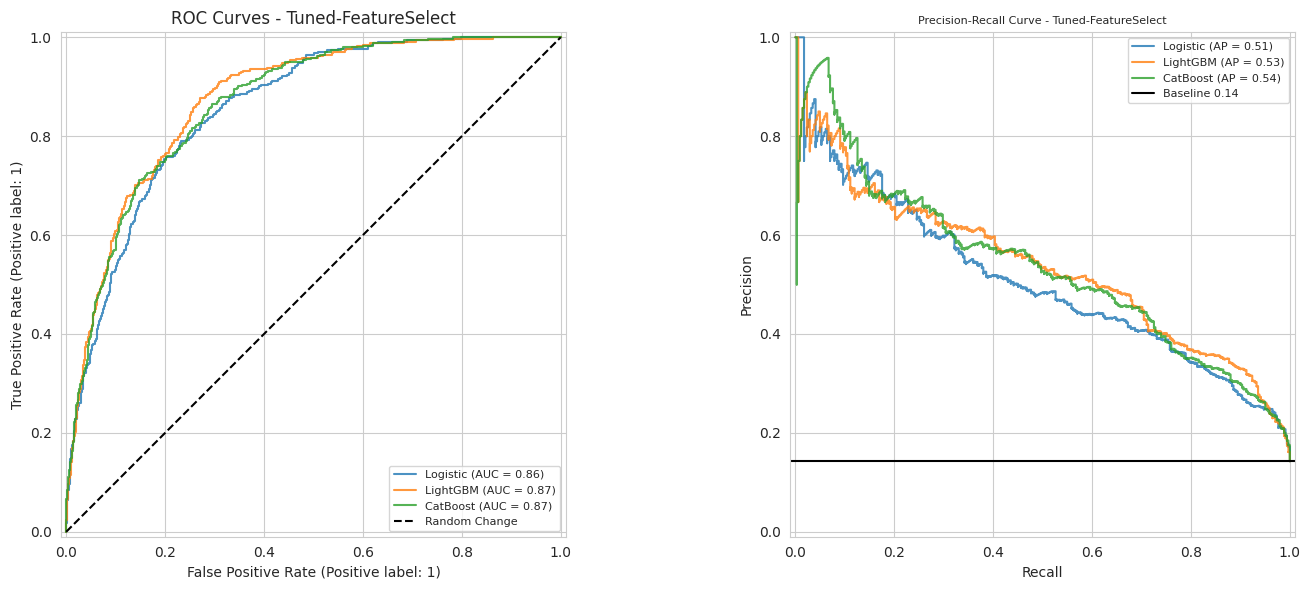

In [96]:
plot_model_comparison(predictions, 'Tuned-FeatureSelect')

# probability calibration

In [97]:
def plot_with_calibration_display(configs, y_test, n_bins=10):

    fig, ax = plt.subplots(figsize=(10, 6))

    for name, model, X_specific in configs:
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_specific)[:, 1]
        else:
            y_prob = model.decision_function(X_specific)
            y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())

        CalibrationDisplay.from_predictions(y_test, y_prob, n_bins=n_bins, name=name, ax=ax, strategy='quantile')

    ax.set_title('Reliability Diagram')
    ax.grid(True, alpha=0.3)
    plt.show()

In [98]:
configs = [
    ('Logistic', best_lr, X_test_linear[common]),
    ('LightGBM', best_lgb, X_test_tree[common]),
    ('CatBoost', best_cb, X_test_tree[common])]

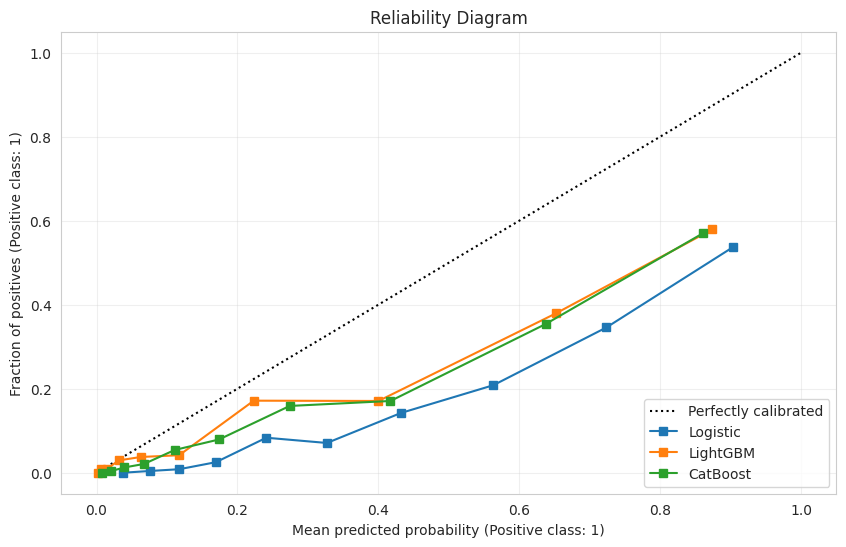

In [99]:
plot_with_calibration_display(configs, y_test)

In [100]:
cal_cb = CalibratedClassifierCV(best_cb, method='sigmoid', cv=5)
cal_lgb = CalibratedClassifierCV(best_lgb, method='sigmoid', cv=5)
cal_lr = CalibratedClassifierCV(best_lr, method='sigmoid', cv=5)

In [101]:
cal_cb.fit(X_train_tree[common], y_train)

,estimator,<catboost.cor...x7f17042fa4d0>
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'


In [102]:
cal_lgb.fit(X_train_tree[common], y_train)

,estimator,"LGBMClassifie...1, verbose=-1)"
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,boosting_type,'gbdt'
,num_leaves,255
,max_depth,10
,learning_rate,0.005
,n_estimators,3000
,subsample_for_bin,200000


In [103]:
cal_lr.fit(X_train_linear[common], y_train)

,estimator,LogisticRegre...r='liblinear')
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1


# ensemble model

In [104]:
def get_oof_probs(configs, y_train, cv=5):
    
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEED)
    oof = {}
    
    for name, model, X_data in configs:
        print(f'Generating Calibrated OOF for {name}')
        probs = np.zeros(len(y_train))

        for train_idx, val_idx in skf.split(X_data, y_train):
            fold_model = clone(model)
            
            if name == 'CatBoost':
                fold_model.set_params(thread_count=-1)
            elif name == 'LightGBM':
                fold_model.set_params(n_jobs=-1)
            elif name == 'Logistic':
                pass
            calibrator = CalibratedClassifierCV(estimator=fold_model, method='sigmoid', cv=3)

            X_train_fold = X_data.iloc[train_idx]
            y_train_fold = y_train.iloc[train_idx]
            X_val_fold = X_data.iloc[val_idx]
            
            calibrator.fit(X_train_fold, y_train_fold)
            probs[val_idx] = calibrator.predict_proba(X_val_fold)[:, 1]
        
        oof[name] = probs
        print(f'Done Generating Calibrated OOF for {name}')
    return oof

In [105]:
configs = [
    ('Logistic', best_lr, X_train_linear[common]),
    ('LightGBM', best_lgb, X_train_tree[common]),
    ('CatBoost', best_cb, X_train_tree[common])]

In [106]:
y_train = pd.Series(y_train)
y_test = pd.Series(y_test)

In [107]:
oof_probs = get_oof_probs(configs, y_train)

Generating Calibrated OOF for Logistic
Done Generating Calibrated OOF for Logistic
Generating Calibrated OOF for LightGBM
Done Generating Calibrated OOF for LightGBM
Generating Calibrated OOF for CatBoost
Done Generating Calibrated OOF for CatBoost


In [108]:
X_meta_train = np.column_stack([oof_probs['Logistic'], oof_probs['LightGBM'], oof_probs['CatBoost']])

meta_learner = LinearRegression(positive=True, fit_intercept=False)
meta_learner.fit(X_meta_train, y_train)

raw_weights = meta_learner.coef_
fair_weights = raw_weights / np.sum(raw_weights)

print(f'Optimal Weights: Logistic={fair_weights[0]:.3f}, LightGBM={fair_weights[1]:.3f}, CatBoost={fair_weights[2]:.3f}')

Optimal Weights: Logistic=0.212, LightGBM=0.422, CatBoost=0.365


In [109]:
oof_ensemble_probs = meta_learner.predict(X_meta_train)
oof_ensemble_probs = np.clip(oof_ensemble_probs, 0, 1)
pr_ensemble = average_precision_score(y_train, oof_ensemble_probs)

print(f'OOF Ensemble PR-AUC: {pr_ensemble:.4f}')

OOF Ensemble PR-AUC: 0.5927


# threshold optimization

In [110]:
best_recall = 0
best_precision = 0
best_threshold = 0

for threshold in np.linspace(0.1, 0.7, 500):
    preds = (oof_ensemble_probs >= threshold).astype(int)
    rec = recall_score(y_train, preds)
    prec = precision_score(y_train, preds, zero_division=0)

    if prec >= 0.30:
        if rec > best_recall:
            best_recall = rec
            best_precision = prec
            best_threshold = threshold

flagged_percentage = (oof_ensemble_probs >= 0.10).mean()
print(f'Optimal Threshold (OOF): {best_threshold:.4f}')
print(f'Anticipated Recall: {best_recall:.4f}')
print(f'Anticipated Precision: {best_precision:.4f}')
print(f'Percentage of patients flagged: {flagged_percentage * 100:.2f}%')

Optimal Threshold (OOF): 0.1000
Anticipated Recall: 0.8593
Anticipated Precision: 0.3545
Percentage of patients flagged: 34.51%


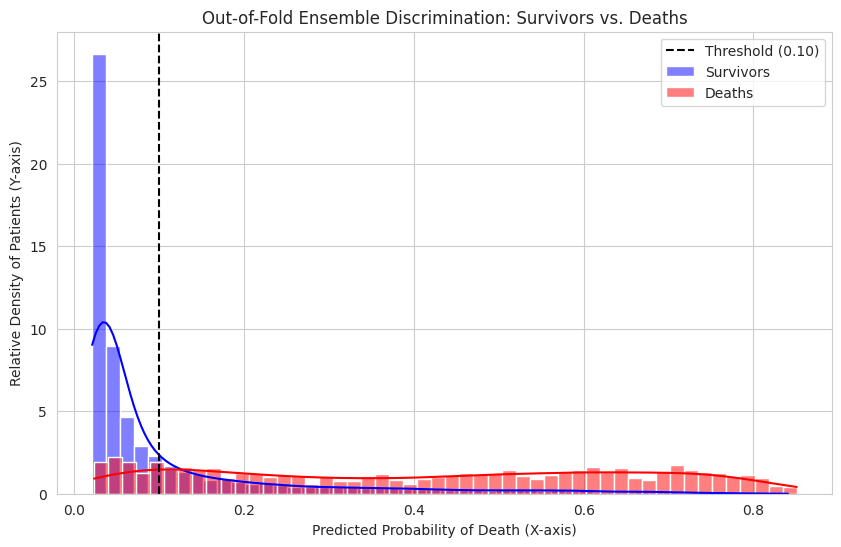

In [111]:
plt.figure(figsize=(10, 6))

sns.histplot(data=None, x=oof_ensemble_probs[y_train == 0], label='Survivors', color='blue', bins=50, kde=True, stat="density", common_norm=False, alpha=0.5)
sns.histplot(data=None, x=oof_ensemble_probs[y_train == 1], label='Deaths', color='red', bins=50, kde=True, stat="density", common_norm=False, alpha=0.5)

plt.axvline(0.10, color='black', linestyle='--', label='Threshold (0.10)')

plt.xlabel('Predicted Probability of Death (X-axis)')
plt.ylabel('Relative Density of Patients (Y-axis)')
plt.title('Out-of-Fold Ensemble Discrimination: Survivors vs. Deaths')
plt.legend()
plt.show()

# final result on test dataset

In [112]:
X_meta_test = np.column_stack([
    cal_lr.predict_proba(X_test_linear[common])[:, 1],
    cal_lgb.predict_proba(X_test_tree[common])[:, 1],
    cal_cb.predict_proba(X_test_tree[common])[:, 1]])

ensemble_probs_pred = meta_learner.predict(X_meta_test)
ensemble_probs_pred = np.clip(ensemble_probs_pred, 0, 1)
optimal_threshold = 0.10
final_preds = (ensemble_probs_pred >= optimal_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, final_preds).ravel()
ensemble_metrics = {
    'Model': 'Ensemble',
    'Strategy': 'EnsembleWeight_Optimized',
    'ROC_AUC': roc_auc_score(y_test, ensemble_probs_pred),
    'PR_AUC': average_precision_score(y_test, ensemble_probs_pred),
    'F1': f1_score(y_test, final_preds),
    'Recall': recall_score(y_test, final_preds),
    'Precision': precision_score(y_test, final_preds, zero_division=0),
    'Specificity': tn / (tn + fp),
    'Accuracy': accuracy_score(y_test, final_preds),
    'TP': tp,
    'TN': tn,
    'FP': fp,
    'FN': fn}

print(f'--- Final Optimized Ensemble Result ---')
for k, v in ensemble_metrics.items():
    print(f'{k}: {v}')

--- Final Optimized Ensemble Result ---
Model: Ensemble
Strategy: EnsembleWeight_Optimized
ROC_AUC: 0.8739675063144241
PR_AUC: 0.5446600258486178
F1: 0.5048888888888889
Recall: 0.8304093567251462
Precision: 0.36270753512132825
Specificity: 0.757295719844358
Accuracy: 0.7677231025854879
TP: 284
TN: 1557
FP: 499
FN: 58


### result table

In [113]:
results.append({
    'Model': ensemble_metrics['Model'], 'Strategy': ensemble_metrics['Strategy'], 'ROC_AUC': ensemble_metrics['ROC_AUC'], 'PR_AUC': ensemble_metrics['PR_AUC'],
    'F1': ensemble_metrics['F1'], 'Recall': ensemble_metrics['Recall'], 'Precision': ensemble_metrics['Precision'],
    'Specificity': ensemble_metrics['Specificity'], 'Accuracy': ensemble_metrics['Accuracy'],
    'TP': ensemble_metrics['TP'], 'TN': ensemble_metrics['TN'], 'FP': ensemble_metrics['FP'], 'FN': ensemble_metrics['FN']})

keys = ensemble_metrics['Model']+'_'+ensemble_metrics['Strategy']
predictions[keys] = (y_test.values, final_preds, ensemble_probs_pred)

In [114]:
#print(predictions)

In [115]:
df_results = pd.DataFrame(results)
df_results

,Model,Strategy,ROC_AUC,PR_AUC,F1,Recall,Precision,Specificity,Accuracy,TP,TN,FP,FN
0,Logistic,SMOTE,0.863701,0.515067,0.508342,0.757310,0.382570,0.796693,0.791076,259,1638,418,83
1,SVC,SMOTE,0.839904,0.439331,0.476858,0.497076,0.458221,0.902237,0.844454,170,1855,201,172
2,RandomForest,SMOTE,0.835044,0.496076,0.490716,0.540936,0.449029,0.889591,0.839867,185,1829,227,157
3,XGBoost,SMOTE,0.869673,0.535876,0.446018,0.368421,0.565022,0.952821,0.869475,126,1959,97,216
4,LightGBM,SMOTE,0.873178,0.541951,0.465950,0.380117,0.601852,0.958171,0.875730,130,1970,86,212
5,CatBoost,SMOTE,0.867302,0.545888,0.458781,0.374269,0.592593,0.957198,0.874062,128,1968,88,214
6,Logistic,Tuned-SMOTE,0.863930,0.515502,0.507205,0.771930,0.377682,0.788424,0.786072,264,1621,435,78
7,SVC,Tuned-SMOTE,0.831021,0.421532,0.245536,0.160819,0.518868,0.975195,0.859049,55,2005,51,287
8,RandomForest,Tuned-SMOTE,0.841150,0.481220,0.467615,0.432749,0.508591,0.930447,0.859466,148,1913,143,194
9,XGBoost,Tuned-SMOTE,0.871137,0.541344,0.437956,0.350877,0.582524,0.958171,0.871560,120,1970,86,222


### confusion matrix, ROC curve, PR curve, feature importance

In [116]:
def get_ensemble_importance(X_cb, X_lgb, X_lr, y_test, meta_learner, n_repeats=5):

    def predict_ensemble_internal(dat_cb, dat_lgb, dat_lr):
        p_lr = cal_lr.predict_proba(dat_lr)[:, 1]
        p_lgb = cal_lgb.predict_proba(dat_lgb)[:, 1]
        p_cb = cal_cb.predict_proba(dat_cb)[:, 1]
        X_meta = np.column_stack([p_lr, p_lgb, p_cb])
        return np.clip(meta_learner.predict(X_meta), 0, 1)

    baseline_auc = roc_auc_score(y_test, predict_ensemble_internal(X_cb, X_lgb, X_lr))
    
    print(f'--- Starting Parallel Permutation: {len(X_cb.columns)} features x {n_repeats} repeats ---')
    start_time = time.time()

    def evaluate_column(col):
        X_cb_local = X_cb.copy()
        X_lgb_local = X_lgb.copy()
        X_lr_local = X_lr.copy()
        
        orig_cb = X_cb_local[col].values.copy()
        orig_lgb = X_lgb_local[col].values.copy() if col in X_lgb_local.columns else None
        orig_lr = X_lr_local[col].values.copy() if col in X_lr_local.columns else None
        
        scores = []
        for _ in range(n_repeats):
            perm_indices = np.random.permutation(len(y_test))
            X_cb_local[col] = orig_cb[perm_indices]
            if orig_lgb is not None: X_lgb_local[col] = orig_lgb[perm_indices]
            if orig_lr is not None: X_lr_local[col] = orig_lr[perm_indices]
            
            y_prob = predict_ensemble_internal(X_cb_local, X_lgb_local, X_lr_local)
            scores.append(roc_auc_score(y_test, y_prob))
            
        return baseline_auc - np.mean(scores)

    importances = Parallel(n_jobs=-1, backend="threading")(delayed(evaluate_column)(col) for col in X_cb.columns)

    print(f'--- Importance Calculation Finished in {time.time() - start_time:.2f} seconds ---')
    return pd.Series(importances, index=X_cb.columns).sort_values(ascending=False)


5.1 Initializing Probability Dictionary...
5.2 Generating (1) Confusion Matrix...
5.3 Calculating (2) Feature Importance (Parallel) ...
--- Starting Parallel Permutation: 101 features x 5 repeats ---


/home/leewen/code/physionet/.venv/lib/python3.10/site-packages/sklearn/utils/_tags.py:338: DeprecationWarning: The following error was raised: 'CatBoostClassifier' object has no attribute '__sklearn_tags__'. It seems that there are no classes that implement `__sklearn_tags__` in the MRO and/or all classes in the MRO call `super().__sklearn_tags__()`. Make sure to inherit from `BaseEstimator` which implements `__sklearn_tags__` (or alternatively define `__sklearn_tags__` but we don't recommend this approach). Note that `BaseEstimator` needs to be on the right side of other Mixins in the inheritance order. The default are now used instead since retrieving tags failed. This warning will be replaced by an error in 1.8.
  warnings.warn(


--- Importance Calculation Finished in 589.88 seconds ---
5.4 Plotting (3) ROC and (4) Precision-Recall Curves...
5.5 Finalizing Layout and Saving File...
Success: Dashboard saved to /home/leewen/code/physionet/ICU_Mortality_Ensemble_Dashboard.png


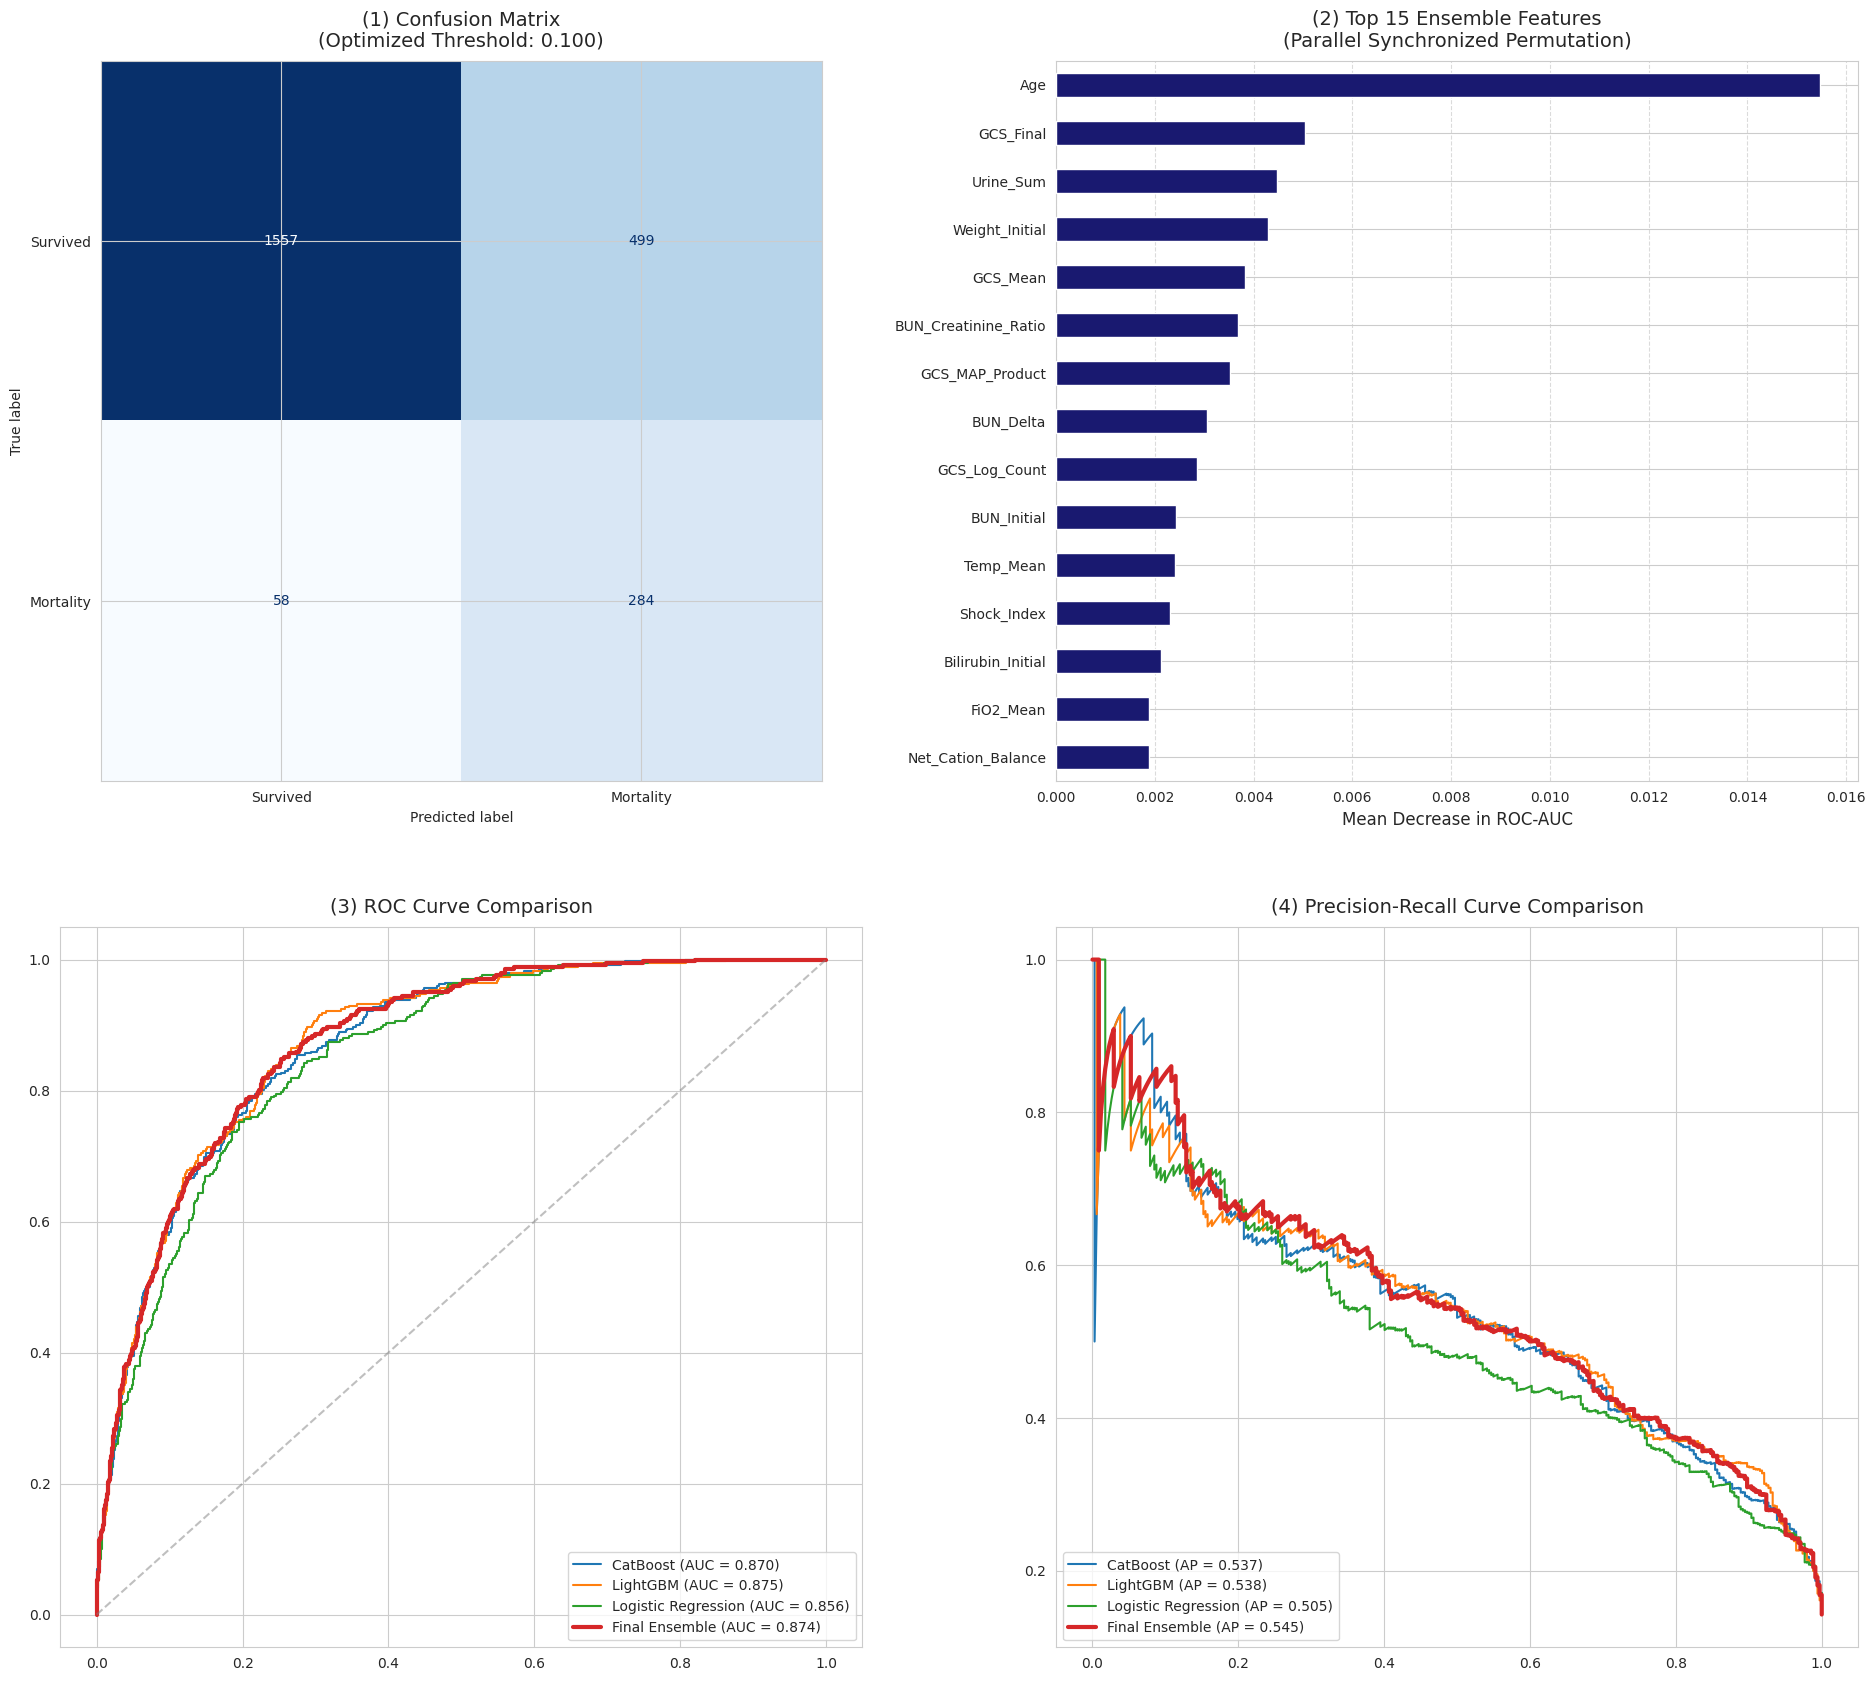

In [117]:
print('\n5.1 Initializing Probability Dictionary...')
prob_dict = {
    'CatBoost': cal_cb.predict_proba(X_test_tree[common])[:, 1],
    'LightGBM': cal_lgb.predict_proba(X_test_tree[common])[:, 1],
    'Logistic Regression': cal_lr.predict_proba(X_test_linear[common])[:, 1],
    'Final Ensemble': ensemble_probs_pred
}

fig, axes = plt.subplots(2, 2, figsize=(20, 18))

print('5.2 Generating (1) Confusion Matrix...')
cm = confusion_matrix(y_test, final_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Survived', 'Mortality'])
disp.plot(ax=axes[0, 0], cmap='Blues', colorbar=False)
axes[0, 0].set_title(f'(1) Confusion Matrix\n(Optimized Threshold: {optimal_threshold:.3f})', fontsize=14, pad=10)

print('5.3 Calculating (2) Feature Importance (Parallel) ...')
feat_imp = get_ensemble_importance(X_test_tree[common], X_test_tree[common], X_test_linear[common], y_test, meta_learner, n_repeats=5)

feat_imp.head(15).plot(ax=axes[0, 1], kind='barh', color='midnightblue', zorder=3)
axes[0, 1].set_title('(2) Top 15 Ensemble Features\n(Parallel Synchronized Permutation)', fontsize=14, pad=10)
axes[0, 1].invert_yaxis()
axes[0, 1].set_xlabel('Mean Decrease in ROC-AUC', fontsize=12)
axes[0, 1].grid(axis='x', linestyle='--', alpha=0.7, zorder=0)

print("5.4 Plotting (3) ROC and (4) Precision-Recall Curves...")
for name, probs in prob_dict.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    score = auc(fpr, tpr)
    linewidth = 3 if 'Final' in name else 1.5
    axes[1, 0].plot(fpr, tpr, label=f'{name} (AUC = {score:.3f})', lw=linewidth)
    
    prec_vals, rec_vals, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    axes[1, 1].plot(rec_vals, prec_vals, label=f'{name} (AP = {ap:.3f})', lw=linewidth)

axes[1, 0].plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.5)
axes[1, 0].set_title('(3) ROC Curve Comparison', fontsize=14, pad=10)
axes[1, 0].legend(loc='lower right')

axes[1, 1].set_title('(4) Precision-Recall Curve Comparison', fontsize=14, pad=10)
axes[1, 1].legend(loc='lower left')

print("5.5 Finalizing Layout and Saving File...")
plt.tight_layout(pad=5.0)
plt.savefig(path+'/ICU_Mortality_Ensemble_Dashboard.png', dpi=300, bbox_inches='tight')
print(f'Success: Dashboard saved to {path}/ICU_Mortality_Ensemble_Dashboard.png')
plt.show()

# output model for deployment

In [118]:
ensemble_deployment_bundle = {
    'cal_lr': cal_lr,
    'cal_lgb': cal_lgb,
    'cal_cb': cal_cb,
    'meta_learner': meta_learner,
    'optimal_threshold': optimal_threshold,
    'feature_cols': common}

joblib.dump(ensemble_deployment_bundle, path+'/icu_mortality_ensemble_v1.joblib')

print('Deployment bundle saved successfully')

Deployment bundle saved successfully
